# 🔴 Deteksi Hate Speech Bahasa Indonesia
## Fuzzy Logic (Mamdani & Sugeno) + Deep Learning (LSTM) — Integrasi Hibrida

**Dataset:** Indonesian Hate Speech Detection Dataset (ID-Hate-Speech-and-Abusive-Language-Detection)  
**Sumber:** https://github.com/okkyibrohim/id-multi-label-hate-speech-and-abusive-language-detection  
**Jumlah Data:** 13.169 baris × 13 variabel

---
### Arsitektur Sistem
```
Input Text
    │
    ▼
[Preprocessing + Feature Extraction]
    │                  │
    ▼                  ▼
[LSTM Deep Learning]  [Fuzzy Feature Engineering]
    │                  │
    └──────┬───────────┘
           ▼
   [Fuzzy Mamdani / Sugeno]
           │
           ▼
     [Output: Severity Score → Label]
```
**Deep Learning MELENGKAPI Fuzzy** (bukan menggantikan):
- LSTM mengekstrak `abusive_score` dari teks (probabilitas kata abusif)
- Skor LSTM menjadi salah satu input variabel Fuzzy
- Fuzzy (Mamdani/Sugeno) yang membuat keputusan akhir


## 1. Import Library & Setup

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

# NLP & Text
import re
import string
from collections import Counter

# Deep Learning
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (Embedding, LSTM, Dense, Dropout,
                                     Bidirectional, GlobalMaxPooling1D, Input)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping

# Metrics
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, f1_score, roc_auc_score,
                              balanced_accuracy_score)
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_selection import chi2

# Visualisasi
import seaborn as sns
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11

np.random.seed(42)
tf.random.set_seed(42)
print('✅ Libraries loaded')
print(f'   TensorFlow: {tf.__version__}')

✅ Libraries loaded
   TensorFlow: 2.21.0


## 2. Load Dataset

In [32]:
# ─────────────────────────────────────────────────────────────
# DATASET
# Sumber: https://github.com/okkyibrohim/id-multi-label-hate-speech-and-abusive-language-detection
# Paper : "Multi-label Hate Speech and Abusive Language Detection
#          in Indonesian Twitter" (Ibrohim & Budi, 2019)
# ─────────────────────────────────────────────────────────────

df       = pd.read_csv('data.csv',           encoding='latin1')
df_abuse = pd.read_csv('abusive.csv',        encoding='utf-8')
df_kamus = pd.read_csv('new_kamusalay.csv',  encoding='latin1', header=0)
df_kamus.columns = ['alay', 'normal']

print(f'📊 Main dataset    : {df.shape[0]:,} baris × {df.shape[1]} kolom')
print(f'📊 Abusive lexicon : {df_abuse.shape[0]:,} kata')
print(f'📊 Kamus alay      : {df_kamus.shape[0]:,} entri')
print()
print('Kolom dataset utama:')
print(df.columns.tolist())
df.head(3)

📊 Main dataset    : 13,169 baris × 13 kolom
📊 Abusive lexicon : 125 kata
📊 Kamus alay      : 15,166 entri

Kolom dataset utama:
['Tweet', 'HS', 'Abusive', 'HS_Individual', 'HS_Group', 'HS_Religion', 'HS_Race', 'HS_Physical', 'HS_Gender', 'HS_Other', 'HS_Weak', 'HS_Moderate', 'HS_Strong']


,Tweet,HS,Abusive,HS_Individual,HS_Group,HS_Religion,HS_Race,HS_Physical,HS_Gender,HS_Other,HS_Weak,HS_Moderate,HS_Strong
0,- disaat semua cowok berusaha melacak perhatia...,1,1,1,0,0,0,0,0,1,1,0,0
1,RT USER: USER siapa yang telat ngasih tau elu?...,0,1,0,0,0,0,0,0,0,0,0,0
2,"41. Kadang aku berfikir, kenapa aku tetap perc...",0,0,0,0,0,0,0,0,0,0,0,0


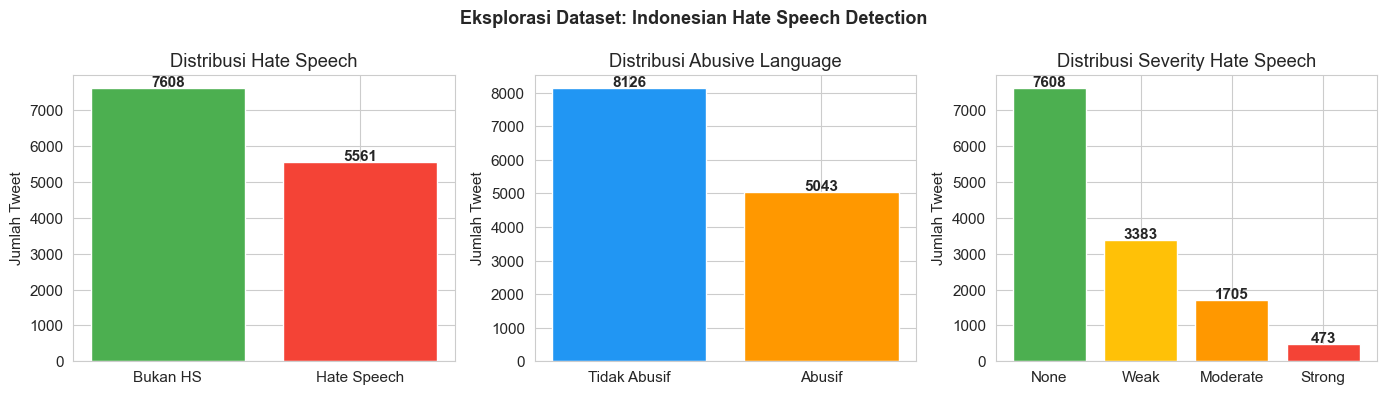

In [33]:
# ── Distribusi Label ──
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

label_cols = {
    'HS (Hate Speech)': 'HS',
    'Abusive': 'Abusive',
    'Severity (HS)': None
}

# Plot 1: HS
hs_counts = df['HS'].value_counts()
axes[0].bar(['Bukan HS', 'Hate Speech'], hs_counts.values, color=['#4CAF50','#F44336'])
axes[0].set_title('Distribusi Hate Speech')
axes[0].set_ylabel('Jumlah Tweet')
for i, v in enumerate(hs_counts.values):
    axes[0].text(i, v+50, str(v), ha='center', fontweight='bold')

# Plot 2: Abusive
ab_counts = df['Abusive'].value_counts()
axes[1].bar(['Tidak Abusif', 'Abusif'], ab_counts.values, color=['#2196F3','#FF9800'])
axes[1].set_title('Distribusi Abusive Language')
axes[1].set_ylabel('Jumlah Tweet')
for i, v in enumerate(ab_counts.values):
    axes[1].text(i, v+50, str(v), ha='center', fontweight='bold')

# Plot 3: Severity
sev_labels = ['None', 'Weak', 'Moderate', 'Strong']
sev_counts = [
    len(df[df['HS']==0]),
    len(df[(df['HS_Weak']==1)&(df['HS_Moderate']==0)&(df['HS_Strong']==0)]),
    len(df[df['HS_Moderate']==1]),
    len(df[df['HS_Strong']==1])
]
colors = ['#4CAF50','#FFC107','#FF9800','#F44336']
axes[2].bar(sev_labels, sev_counts, color=colors)
axes[2].set_title('Distribusi Severity Hate Speech')
axes[2].set_ylabel('Jumlah Tweet')
for i, v in enumerate(sev_counts):
    axes[2].text(i, v+50, str(v), ha='center', fontweight='bold')

plt.suptitle('Eksplorasi Dataset: Indonesian Hate Speech Detection', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('dist_label.png', bbox_inches='tight')
plt.show()

## 3. Preprocessing Teks

In [34]:
# ── Kamus normalisasi alay ──
alay_dict = dict(zip(df_kamus['alay'].str.lower(), df_kamus['normal'].str.lower()))
abusive_set = set(df_abuse['ABUSIVE'].str.lower().str.strip())

# Tambahan manual untuk slang/typo umum yang sering muncul pada tweet informal.
# Ini melengkapi kamus alay dari dataset, bukan menggantikannya.
custom_slang_dict = {
    'loe': 'lu',
    'lo': 'lu',
    'elu': 'lu',
    'luu': 'lu',
    'gua': 'gue',
    'gw': 'gue',
    'guee': 'gue',
    'gk': 'tidak',
    'ga': 'tidak',
    'gak': 'tidak',
    'nggak': 'tidak',
    'ngga': 'tidak',
    'tdk': 'tidak',
    'bgt': 'banget',
    'bngt': 'banget',
    'sm': 'sama',
    'yg': 'yang',
    'dgn': 'dengan',
    'utk': 'untuk',
    'anjg': 'anjing',
    'anj': 'anjing',
    'anjir': 'anjing',
    'anjrit': 'anjing',
    'bgst': 'bangsat',
    'bgsd': 'bangsat',
    'gblk': 'goblok',
    'goblog': 'goblok',
    'tololll': 'tolol',
    'idiottt': 'idiot',
    'bego': 'bodoh',
    'begok': 'bodoh'
}

# Update setelah alay_dict dibuat supaya custom slang bisa menjadi fallback tambahan.
alay_dict.update(custom_slang_dict)

print(f'Kamus alay + custom slang : {len(alay_dict):,} entri')
print(f'Lexicon abusif            : {len(abusive_set):,} kata')

def normalize_alay(text):
    words = text.split()
    return ' '.join(alay_dict.get(w, w) for w in words)

def preprocess_text(text):
    """Preprocessing pipeline:
       lowercase → remove USER/RT/URL → remove punctuation
       → normalize alay/slang → strip extra spaces"""
    if not isinstance(text, str):
        return ''
    text = text.lower()
    text = re.sub(r'\buser\b|\brt\b|\burl\b', '', text)  # token khusus
    text = re.sub(r'http\S+|www\S+', '', text)             # URL
    text = re.sub(r'[^a-z0-9\s]', ' ', text)               # punctuation
    text = normalize_alay(text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean_tweet'] = df['Tweet'].apply(preprocess_text)
print()
print('Contoh preprocessing:')
for i in range(3):
    print(f'  Asli  : {df["Tweet"].iloc[i][:80]}')
    print(f'  Bersih: {df["clean_tweet"].iloc[i][:80]}')
    print()


Kamus alay + custom slang : 15,171 entri
Lexicon abusif            : 125 kata

Contoh preprocessing:
  Asli  : - disaat semua cowok berusaha melacak perhatian gue. loe lantas remehkan perhati
  Bersih: di saat semua cowok berusaha melacak perhatian gue lu lantas remehkan perhatian 

  Asli  : RT USER: USER siapa yang telat ngasih tau elu?edan sarap gue bergaul dengan ciga
  Bersih: siapa yang telat memberi tau lu edan sarap gue bergaul dengan cigax jifla calis 

  Asli  : 41. Kadang aku berfikir, kenapa aku tetap percaya pada Tuhan padahal aku selalu 
  Bersih: 41 kadang aku berpikir kenapa aku tetap percaya pada tuhan padahal aku selalu ja



## 4. Feature Engineering — Input Variabel Fuzzy
### 5 Input Variabel Linguistik:
| # | Variabel | Cara Ekstraksi |
|---|----------|----------------|
| 1 | `abusive_word_ratio` | Rasio kata abusif / total kata (dari lexicon) |
| 2 | `hs_keyword_score`   | Skor kata kunci hate speech (HS_Individual+Group+Religion+Race) |
| 3 | `tweet_negativity`   | Jumlah negasi + intensifier negatif |
| 4 | `target_specificity` | Apakah ada target spesifik (individu/kelompok) |
| 5 | `dl_abusive_prob`    | Probabilitas abusif dari LSTM (BONUS DL) |

In [ ]:
# ── Kamus kata kunci awal ──
# Catatan:
# - Ini hanya seed manual.
# - Setelah train/validation/test split, keyword akan DIPERKAYA dari train set saja
#   agar tidak mengambil informasi dari test set.

hs_keywords = list(set([
    'kafir','bangsat','babi','anjing','tolol','bodoh','goblok','idiot',
    'monyet','kampret','bajingan','laknat','haram','sesat','murtad',
    'penjajah','asing','cina','pribumi','komunis','teroris',
    'pendatang','cacian','hina','rendah','sampah','brengsek','setan',
    'dungu','biadab','najis','busuk','penista','antek','pengkhianat',
    'cebong','kampret','pki','antek asing','pengkhianat bangsa'
]))

negative_emotion_words = list(set([
    'benci','hina','menghina','cacian','caci','rendah','sampah',
    'jijik','muak','najis','busuk','marah','laknat','brengsek',
    'bodoh','tolol','goblok','idiot','bangsat','biadab'
]))

intensifier_words = [
    'sangat','banget','sekali','amat','betul','memang','sungguh',
    'terlalu','paling'
]

target_terms = list(set([
    # pronoun / direct target
    'kamu','kau','lu','anda','dia','mereka','kalian',

    # group markers
    'orang','kaum','kelompok','golongan','bangsa','warga','rakyat',
    'pendukung','simpatisan','komunitas',

    # identity / social / political / religion / race markers
    'islam','muslim','kristen','katolik','hindu','budha',
    'cina','china','tionghoa','pribumi','asing','arab',
    'komunis','pki','liberal','cebong','kampret',

    # gender / demographic
    'perempuan','wanita','laki','lelaki','cowok','cewek'
]))

def abusive_word_ratio(text):
    """
    Feature fuzzy untuk intensitas kata abusif.
    Menggabungkan ratio dan jumlah kata abusif supaya tweet pendek tidak terlalu bias.
    """
    words = text.split()
    if not words:
        return 0.0

    count = sum(1 for w in words if w in abusive_set)
    ratio_score = count / len(words)
    count_score = min(count / 3.0, 1.0)

    # Ratio menangkap kepadatan, count menangkap banyaknya kata kasar.
    return max(ratio_score, count_score * 0.75)

def hs_keyword_score(text):
    """
    Skor berdasarkan keyword hate speech.
    Mendukung unigram dan bigram dengan token matching.
    """
    tokens = text.split()
    unigram_set = set(tokens)

    bigram_set = set(
        f'{tokens[i]} {tokens[i+1]}'
        for i in range(len(tokens) - 1)
    )

    term_set = unigram_set.union(bigram_set)

    hits = 0
    for kw in hs_keywords:
        kw = kw.strip()
        if kw in term_set:
            hits += 1

    return min(hits / 4.0, 1.0)

def tweet_negativity(text):
    """
    Skor negatif berdasarkan kata emosi negatif + intensifier.
    Tidak memakai negation words seperti 'tidak', 'bukan', 'jangan',
    karena negasi tidak selalu berarti ujaran negatif.
    """
    words = text.split()

    neg_hits = sum(1 for w in words if w in negative_emotion_words)
    intensifier_hits = sum(1 for w in words if w in intensifier_words)

    raw = neg_hits + (0.25 * intensifier_hits)
    return min(raw / 4.0, 1.0)

def target_specificity_text(text):
    """
    Target specificity berasal dari teks, bukan dari kolom label anotasi dataset.
    """
    words = set(text.split())
    hits = sum(1 for term in target_terms if term in words)
    return min(hits / 3.0, 1.0)

def emphasis_score(raw_text):
    """
    Fitur gaya agresif:
    - Banyak tanda seru
    - Proporsi huruf kapital tinggi
    Tetapi token placeholder USER/URL/RT tidak dihitung.
    """
    if not isinstance(raw_text, str) or len(raw_text) == 0:
        return 0.0

    # Remove dataset placeholders first
    text = re.sub(r'\b(USER|URL|RT)\b', ' ', raw_text)
    text = re.sub(r'http\S+|www\S+', ' ', text)

    exclamation_count = text.count('!')

    # Count uppercase only among alphabetic characters
    alpha_chars = [c for c in text if c.isalpha()]
    if not alpha_chars:
        uppercase_score = 0.0
    else:
        uppercase_count = sum(1 for c in alpha_chars if c.isupper())

        # Avoid treating tiny uppercase noise as emphasis
        if uppercase_count < 4:
            uppercase_score = 0.0
        else:
            uppercase_ratio = uppercase_count / len(alpha_chars)
            uppercase_score = min(uppercase_ratio / 0.30, 1.0)

    exclamation_score = min(exclamation_count / 3.0, 1.0)

    return max(exclamation_score, uppercase_score)

# Ekstraksi fitur fuzzy dari teks
df['f_abusive_ratio'] = df['clean_tweet'].apply(abusive_word_ratio)
df['f_hs_keyword']    = df['clean_tweet'].apply(hs_keyword_score)
df['f_negativity']    = df['clean_tweet'].apply(tweet_negativity)
df['f_target_spec']   = df['clean_tweet'].apply(target_specificity_text)
df['f_emphasis']      = df['clean_tweet'].apply(emphasis_score)

# Ground truth severity numeric
def severity_numeric(row):
    if row['HS'] == 0:
        return 0.0
    elif row['HS_Weak'] == 1 and row['HS_Moderate'] == 0:
        return 0.33
    elif row['HS_Moderate'] == 1:
        return 0.66
    elif row['HS_Strong'] == 1:
        return 1.0
    else:
        return 0.33

df['severity_score'] = df.apply(severity_numeric, axis=1)

print('✅ Fitur fuzzy awal berhasil diekstraksi')
print()

feature_cols = [
    'f_abusive_ratio',
    'f_hs_keyword',
    'f_negativity',
    'f_target_spec',
    'f_emphasis'
]

print(df[feature_cols + ['severity_score']].describe().round(3))


✅ Fitur fuzzy awal berhasil diekstraksi

       f_abusive_ratio  f_hs_keyword  f_negativity  f_target_spec  f_emphasis  \
count        13169.000     13169.000     13169.000      13169.000   13169.000   
mean             0.209         0.108         0.038          0.237       0.393   
std              0.218         0.177         0.105          0.283       0.302   
min              0.000         0.000         0.000          0.000       0.000   
25%              0.000         0.000         0.000          0.000       0.153   
50%              0.250         0.000         0.000          0.000       0.317   
75%              0.250         0.250         0.000          0.333       0.571   
max              1.000         1.000         1.000          1.000       1.000   

       severity_score  
count       13169.000  
mean            0.206  
std             0.279  
min             0.000  
25%             0.000  
50%             0.000  
75%             0.330  
max             1.000  


In [36]:
# ═══════════════════════════════════════════════════════════════
# TRAIN / VALIDATION / TEST SPLIT
# ═══════════════════════════════════════════════════════════════

from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    df,
    test_size=0.40,
    random_state=42,
    stratify=df['HS']
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42,
    stratify=temp_df['HS']
)

train_idx = train_df.index
val_idx   = val_df.index
test_idx  = test_df.index

print(f'Train      : {len(train_df):,}')
print(f'Validation : {len(val_df):,}')
print(f'Test       : {len(test_df):,}')

print()
print('Distribusi HS:')
print('Train:')
print(train_df['HS'].value_counts(normalize=True).round(3))
print('Validation:')
print(val_df['HS'].value_counts(normalize=True).round(3))
print('Test:')
print(test_df['HS'].value_counts(normalize=True).round(3))

Train      : 7,901
Validation : 2,634
Test       : 2,634

Distribusi HS:
Train:
HS
0    0.578
1    0.422
Name: proportion, dtype: float64
Validation:
HS
0    0.577
1    0.423
Name: proportion, dtype: float64
Test:
HS
0    0.578
1    0.422
Name: proportion, dtype: float64


### 4.1 Train-set Keyword Mining untuk Memperkuat Fitur `f_hs_keyword`


In [37]:
# ═══════════════════════════════════════════════════════════════
# TRAIN-ONLY KEYWORD MINING
# ═══════════════════════════════════════════════════════════════
# Tujuan:
# - Memperkuat f_hs_keyword tanpa memakai test set.
# - Keyword diambil hanya dari train_df, lalu dipakai untuk menghitung ulang fitur
#   pada train/validation/test.

manual_hs_keywords = set(hs_keywords)

vectorizer_kw = CountVectorizer(
    max_features=8000,
    ngram_range=(1, 2),
    min_df=3
)

X_kw_train = vectorizer_kw.fit_transform(train_df['clean_tweet'])
y_kw_train = train_df['HS'].values

chi_scores, p_values = chi2(X_kw_train, y_kw_train)
feature_names = np.array(vectorizer_kw.get_feature_names_out())

# Hitung seberapa sering term muncul di HS dibandingkan base rate.
X_presence = (X_kw_train > 0)
term_count_total = np.asarray(X_presence.sum(axis=0)).ravel()
term_count_hs = np.asarray(X_presence[y_kw_train == 1].sum(axis=0)).ravel()

term_hs_rate = term_count_hs / np.maximum(term_count_total, 1)
base_hs_rate = y_kw_train.mean()

keyword_scores_df = pd.DataFrame({
    'term': feature_names,
    'chi2': chi_scores,
    'p_value': p_values,
    'count_total': term_count_total,
    'count_hs': term_count_hs,
    'hs_rate': term_hs_rate
}).sort_values(['chi2', 'hs_rate'], ascending=False)

# Stopword/generic terms yang biasanya tidak cukup spesifik untuk hate speech.
generic_blocklist = {
    'yang','dan','di','ke','dari','ini','itu','ada','jadi','untuk','dengan',
    'karena','kalau','saya','aku','gue','lu','dia','mereka','kita','kami',
    'tidak','bukan','jangan','akan','bisa','sudah','belum','dalam','pada',
    'atau','sama','aja','juga','lebih','seperti','orang','para'
}

def is_good_keyword(term):
    if term in generic_blocklist:
        return False
    if len(term) <= 2:
        return False
    if term.isdigit():
        return False
    # Hindari bigram yang semua katanya generic.
    parts = term.split()
    if len(parts) > 1 and all(p in generic_blocklist for p in parts):
        return False
    return True

candidate_keywords = (
    keyword_scores_df[
        (keyword_scores_df['count_total'] >= 3) &
        (keyword_scores_df['hs_rate'] >= base_hs_rate + 0.08)
    ]
    .query("p_value <= 0.10")
    .copy()
)

mined_keywords = [
    term for term in candidate_keywords['term'].head(100).tolist()
    if is_good_keyword(term)
]

# Gabungkan manual keyword + hasil mining.
hs_keywords = sorted(manual_hs_keywords.union(mined_keywords))

# Hitung ulang fitur keyword setelah keyword diperkuat.
df['f_hs_keyword'] = df['clean_tweet'].apply(hs_keyword_score)

print(f'Base HS rate train set       : {base_hs_rate:.3f}')
print(f'Manual keywords              : {len(manual_hs_keywords)}')
print(f'Mined train-only keywords    : {len(mined_keywords)}')
print(f'Total keywords after mining  : {len(hs_keywords)}')
print()
print('Top mined keyword candidates:')
display(candidate_keywords.head(20)[['term', 'chi2', 'count_total', 'count_hs', 'hs_rate']])
print()
print('Updated f_hs_keyword distribution:')
print(df['f_hs_keyword'].describe().round(3))


Base HS rate train set       : 0.422
Manual keywords              : 39
Mined train-only keywords    : 98
Total keywords after mining  : 120

Top mined keyword candidates:


,term,chi2,count_total,count_hs,hs_rate
1273,cebong,419.007748,302,290,0.960265
50,2019 ganti,225.788742,180,160,0.888889
199,ahok,224.468698,197,180,0.913706
2296,ganti presiden,210.363884,206,173,0.839806
4146,lu,200.089321,237,189,0.797468
2295,ganti,191.791275,242,191,0.789256
47,2019,166.056537,277,202,0.729242
1139,bubarkan,125.304840,88,87,0.988636
4088,lengserkan,124.524880,88,88,1.000000
5859,prabowo,120.180631,162,136,0.839506



Updated f_hs_keyword distribution:
count    13169.000
mean         0.332
std          0.335
min          0.000
25%          0.000
50%          0.250
75%          0.500
max          1.000
Name: f_hs_keyword, dtype: float64


## 5. Deep Learning — LSTM untuk Ekstraksi Fitur Abusive Score
**Peran DL:** LSTM menghasilkan `dl_abusive_prob` → menjadi input variabel ke-5 Fuzzy  
**DL TIDAK menggantikan Fuzzy** — hanya memperkaya fitur input

In [38]:
# ── Tokenisasi untuk LSTM ──

MAX_WORDS = 15000
MAX_LEN   = 100
EMBED_DIM = 64

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')

# Fit tokenizer only on train data
tokenizer.fit_on_texts(train_df['clean_tweet'])

def texts_to_padded_sequences(texts):
    sequences = tokenizer.texts_to_sequences(texts)
    return pad_sequences(
        sequences,
        maxlen=MAX_LEN,
        padding='post',
        truncating='post'
    )

X_train = texts_to_padded_sequences(train_df['clean_tweet'])
X_val   = texts_to_padded_sequences(val_df['clean_tweet'])
X_test  = texts_to_padded_sequences(test_df['clean_tweet'])

y_train = train_df['Abusive'].values
y_val   = val_df['Abusive'].values
y_test  = test_df['Abusive'].values

print(f'Vocabulary size: {len(tokenizer.word_index):,}')
print(f'X_train shape  : {X_train.shape}')
print(f'X_val shape    : {X_val.shape}')
print(f'X_test shape   : {X_test.shape}')

print()
print(f'Train target distribusi: {Counter(y_train)}')
print(f'Val target distribusi  : {Counter(y_val)}')
print(f'Test target distribusi : {Counter(y_test)}')

Vocabulary size: 15,327
X_train shape  : (7901, 100)
X_val shape    : (2634, 100)
X_test shape   : (2634, 100)

Train target distribusi: Counter({np.int64(0): 4835, np.int64(1): 3066})
Val target distribusi  : Counter({np.int64(0): 1655, np.int64(1): 979})
Test target distribusi : Counter({np.int64(0): 1636, np.int64(1): 998})


In [39]:
# ── Arsitektur LSTM ──
model_lstm = Sequential([
    Embedding(MAX_WORDS, EMBED_DIM, input_length=MAX_LEN),
    Bidirectional(LSTM(64, return_sequences=True)),
    GlobalMaxPooling1D(),
    Dense(64, activation='relu'),
    Dropout(0.4),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid', name='abusive_output')
], name='BiLSTM_AbusiveDetector')

model_lstm.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
model_lstm.summary()

Model: "BiLSTM_AbusiveDetector"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_1          │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ abusive_output (Dense)          │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
124/124 ━━━━━━━━━━━━━━━━━━━━ 7s 37ms/step - accuracy: 0.7074 - loss: 0.5537 - val_accuracy: 0.8485 - val_loss: 0.3927
Epoch 2/15
124/124 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - accuracy: 0.9237 - loss: 0.2122 - val_accuracy: 0.9039 - val_loss: 0.2919
Epoch 3/15
124/124 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - accuracy: 0.9711 - loss: 0.0992 - val_accuracy: 0.9089 - val_loss: 0.3089
Epoch 4/15
124/124 ━━━━━━━━━━━━━━━━━━━━ 6s 44ms/step - accuracy: 0.9856 - loss: 0.0550 - val_accuracy: 0.9093 - val_loss: 0.3170
Epoch 5/15
124/124 ━━━━━━━━━━━━━━━━━━━━ 5s 41ms/step - accuracy: 0.9905 - loss: 0.0376 - val_accuracy: 0.8952 - val_loss: 0.4076


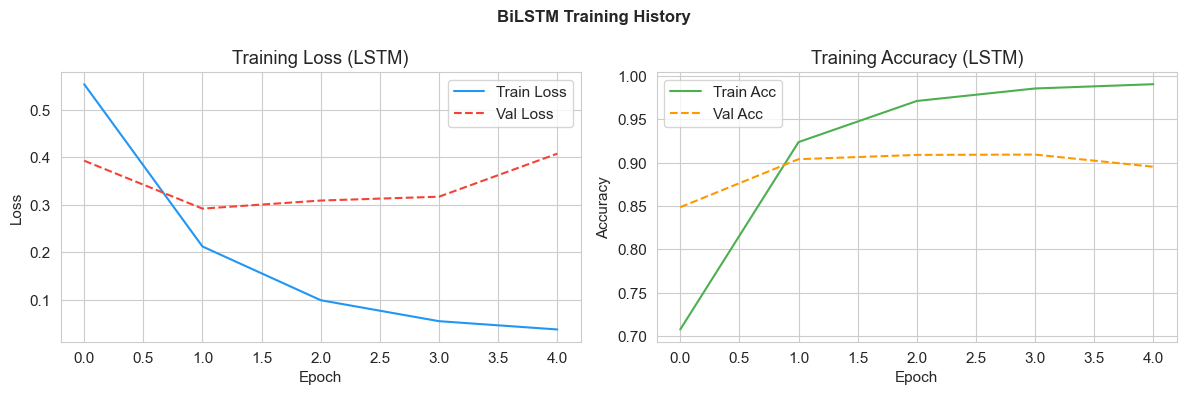

In [40]:
# ── Training LSTM ──
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history = model_lstm.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=15,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

# ── Plot Training History ──
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['loss'],     label='Train Loss', color='#2196F3')
axes[0].plot(history.history['val_loss'], label='Val Loss',   color='#F44336', linestyle='--')
axes[0].set_title('Training Loss (LSTM)')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(history.history['accuracy'],     label='Train Acc', color='#4CAF50')
axes[1].plot(history.history['val_accuracy'], label='Val Acc',   color='#FF9800', linestyle='--')
axes[1].set_title('Training Accuracy (LSTM)')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.suptitle('BiLSTM Training History', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('lstm_history.png', bbox_inches='tight')
plt.show()

In [41]:
# ── Evaluasi LSTM standalone ──

y_prob_train = model_lstm.predict(X_train, batch_size=128, verbose=0).flatten()
y_prob_val   = model_lstm.predict(X_val,   batch_size=128, verbose=0).flatten()
y_prob_test  = model_lstm.predict(X_test,  batch_size=128, verbose=0).flatten()

y_pred_test = (y_prob_test >= 0.5).astype(int)

print('=== Evaluasi LSTM Standalone pada Test Set ===')
print(classification_report(y_test, y_pred_test, target_names=['Tidak Abusif','Abusif']))
print(f'Accuracy : {accuracy_score(y_test, y_pred_test):.4f}')
print(f'ROC-AUC  : {roc_auc_score(y_test, y_prob_test):.4f}')

# Masukkan skor DL ke dataframe sesuai split
df['f_dl_abusive'] = np.nan

df.loc[train_idx, 'f_dl_abusive'] = y_prob_train
df.loc[val_idx,   'f_dl_abusive'] = y_prob_val
df.loc[test_idx,  'f_dl_abusive'] = y_prob_test

print()
print('✅ f_dl_abusive berhasil ditambahkan sebagai variabel input ke-5 untuk sistem hybrid')

=== Evaluasi LSTM Standalone pada Test Set ===
              precision    recall  f1-score   support

Tidak Abusif       0.90      0.97      0.93      1636
      Abusif       0.94      0.83      0.88       998

    accuracy                           0.91      2634
   macro avg       0.92      0.90      0.91      2634
weighted avg       0.92      0.91      0.91      2634

Accuracy : 0.9146
ROC-AUC  : 0.9665

✅ f_dl_abusive berhasil ditambahkan sebagai variabel input ke-5 untuk sistem hybrid


## 6. Desain Sistem Fuzzy Logic — From Scratch
### 6.1 Variabel Linguistik & Fungsi Keanggotaan

In [42]:
# ═══════════════════════════════════════════════════════════════
# FUNGSI KEANGGOTAAN (MEMBERSHIP FUNCTIONS) — FROM SCRATCH
# ═══════════════════════════════════════════════════════════════

def _return_scalar_if_scalar_input(x_original, y):
    if np.isscalar(x_original):
        return float(y)
    return y


def trimf(x, a, b, c):
    x_original = x
    x = np.asarray(x, dtype=float)
    y = np.zeros_like(x, dtype=float)

    # left slope
    if b != a:
        idx = (a < x) & (x < b)
        y[idx] = (x[idx] - a) / (b - a)

    # peak
    y[x == b] = 1.0

    # right slope
    if c != b:
        idx = (b < x) & (x < c)
        y[idx] = (c - x[idx]) / (c - b)

    return _return_scalar_if_scalar_input(x_original, y)


def trapmf(x, a, b, c, d):
    x_original = x
    x = np.asarray(x, dtype=float)
    y = np.zeros_like(x, dtype=float)

    # left shoulder: a == b
    if a == b:
        y[x <= b] = 1.0
    else:
        idx = (a < x) & (x < b)
        y[idx] = (x[idx] - a) / (b - a)

    # plateau
    idx = (b <= x) & (x <= c)
    y[idx] = 1.0

    # right shoulder: c == d
    if c == d:
        y[x >= c] = 1.0
    else:
        idx = (c < x) & (x < d)
        y[idx] = (d - x[idx]) / (d - c)

    # outside range
    y[x < a] = 0.0
    y[x > d] = 0.0

    return _return_scalar_if_scalar_input(x_original, y)


def gaussmf(x, mean, sigma):
    x_original = x
    x = np.asarray(x, dtype=float)
    y = np.exp(-0.5 * ((x - mean) / sigma) ** 2)

    return _return_scalar_if_scalar_input(x_original, y)

# ═══════════════════════════════════════════════════════════════
# DEFINISI VARIABEL LINGUISTIK INPUT
# ═══════════════════════════════════════════════════════════════

# Variabel 1: Abusive Word Ratio / Score
def mf_abusive_ratio(x):
    return {
        'rendah' : trapmf(x, 0.00, 0.00, 0.05, 0.15),
        'sedang' : trimf (x, 0.08, 0.20, 0.35),
        'tinggi' : trapmf(x, 0.25, 0.40, 1.00, 1.00)
    }

# Variabel 2: HS Keyword Score
def mf_hs_keyword(x):
    return {
        'rendah' : trapmf(x, 0.00, 0.00, 0.05, 0.15),
        'sedang' : trimf (x, 0.08, 0.20, 0.35),
        'tinggi' : trapmf(x, 0.25, 0.40, 1.00, 1.00)
    }

# Variabel 3: Tweet Negativity
def mf_negativity(x):
    return {
        'positif' : trapmf(x, 0.00, 0.00, 0.05, 0.20),
        'netral'  : trimf (x, 0.10, 0.25, 0.45),
        'negatif' : trapmf(x, 0.35, 0.55, 1.00, 1.00)
    }

# Variabel 4: Target Specificity
def mf_target(x):
    return {
        'umum'    : trapmf(x, 0.00, 0.00, 0.20, 0.45),
        'spesifik': trapmf(x, 0.30, 0.55, 1.00, 1.00)
    }

# Variabel 5: Emphasis / Aggressive Style
def mf_emphasis(x):
    return {
        'rendah' : trapmf(x, 0.00, 0.00, 0.10, 0.25),
        'sedang' : trimf (x, 0.15, 0.35, 0.55),
        'tinggi' : trapmf(x, 0.45, 0.65, 1.00, 1.00)
    }

# Variabel 6: DL Abusive Probability
def mf_dl_abusive(x):
    return {
        'rendah' : trapmf(x, 0.00, 0.00, 0.25, 0.45),
        'sedang' : trimf (x, 0.30, 0.50, 0.70),
        'tinggi' : trapmf(x, 0.60, 0.75, 1.00, 1.00)
    }

# Variabel Output: Hate Speech Severity (0-1)
def mf_severity(x):
    return {
        'aman'    : trapmf(x, 0,   0,    0.15, 0.30),
        'lemah'   : trimf (x, 0.15,0.33, 0.50),
        'sedang'  : trimf (x, 0.40,0.55, 0.70),
        'kuat'    : trapmf(x, 0.60,0.80, 1.0,  1.0)
    }

print('✅ Fungsi keanggotaan berhasil didefinisikan (8 MF sets, from scratch)')


✅ Fungsi keanggotaan berhasil didefinisikan (8 MF sets, from scratch)


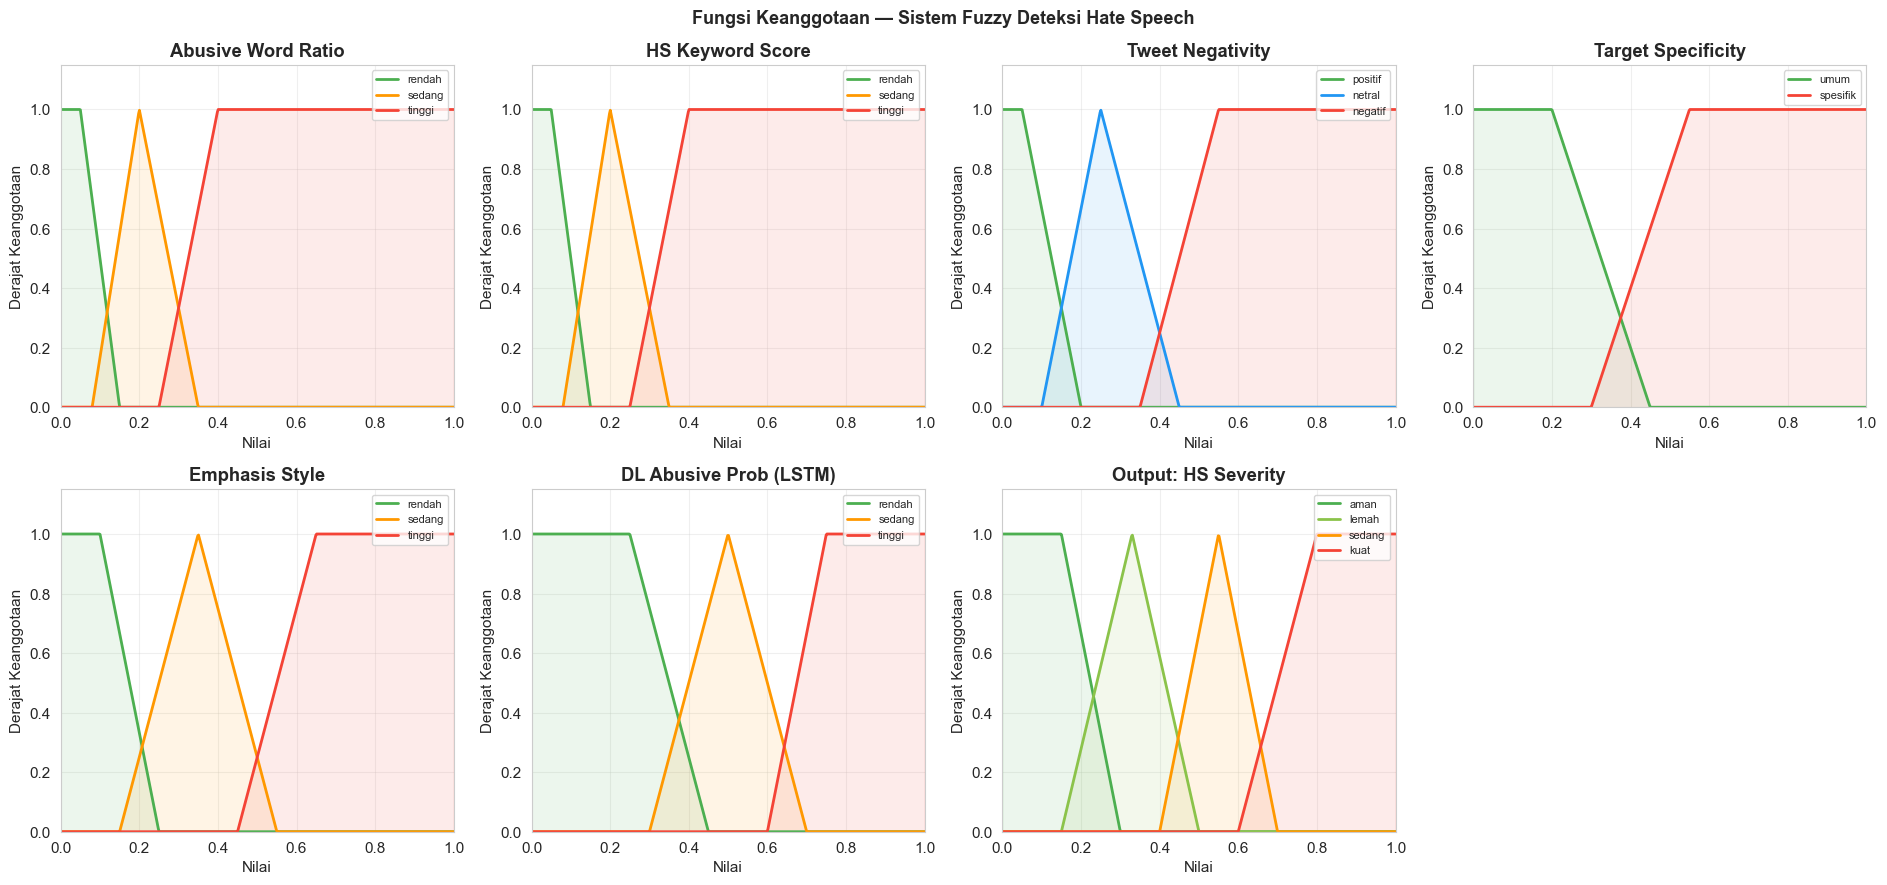

In [43]:
# ── Visualisasi Membership Functions ──
x_range = np.linspace(0, 1, 500)

mf_defs = [
    ('Abusive Word Ratio', mf_abusive_ratio, {'rendah':'#4CAF50','sedang':'#FF9800','tinggi':'#F44336'}),
    ('HS Keyword Score',   mf_hs_keyword,    {'rendah':'#4CAF50','sedang':'#FF9800','tinggi':'#F44336'}),
    ('Tweet Negativity',   mf_negativity,    {'positif':'#4CAF50','netral':'#2196F3','negatif':'#F44336'}),
    ('Target Specificity', mf_target,        {'umum':'#4CAF50','spesifik':'#F44336'}),
    ('Emphasis Style',     mf_emphasis,      {'rendah':'#4CAF50','sedang':'#FF9800','tinggi':'#F44336'}),
    ('DL Abusive Prob (LSTM)', mf_dl_abusive, {'rendah':'#4CAF50','sedang':'#FF9800','tinggi':'#F44336'}),
    ('Output: HS Severity',mf_severity,      {'aman':'#4CAF50','lemah':'#8BC34A','sedang':'#FF9800','kuat':'#F44336'}),
]

fig, axes = plt.subplots(2, 4, figsize=(19, 9))
axes = axes.flatten()

for ax, (title, mf_fn, color_map) in zip(axes, mf_defs):
    mf_vals = mf_fn(x_range)
    for label, y in mf_vals.items():
        ax.plot(x_range, y, label=label, color=color_map.get(label,'gray'), linewidth=2)
        ax.fill_between(x_range, y, alpha=0.1, color=color_map.get(label,'gray'))
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Nilai'); ax.set_ylabel('Derajat Keanggotaan')
    ax.legend(loc='upper right', fontsize=8)
    ax.set_ylim(0, 1.15); ax.set_xlim(0, 1)
    ax.grid(True, alpha=0.3)

# Kosongkan axis terakhir kalau jumlah plot < jumlah subplot
for ax in axes[len(mf_defs):]:
    ax.axis('off')

plt.suptitle('Fungsi Keanggotaan — Sistem Fuzzy Deteksi Hate Speech',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('membership_functions.png', bbox_inches='tight')
plt.show()


### 6.2 Rule Base (≥15 Rules)

In [44]:
# ═══════════════════════════════════════════════════════════════
# RULE BASE — PURE FUZZY DAN HYBRID FUZZY DIPISAH
# ═══════════════════════════════════════════════════════════════

# Pure fuzzy:
# Input = abusive_ratio, hs_keyword, negativity, target_spec
# Tidak memakai DL.

rules_pure = [
    # AMAN
    {'ar':'rendah','hs':'rendah','neg':'positif','tgt':'umum',     'dl':None, 'out':'aman',   'w':1.0},
    {'ar':'rendah','hs':'rendah','neg':None,     'tgt':'umum',     'dl':None, 'out':'aman',   'w':0.9},
    {'ar':'rendah','hs':'rendah','neg':'netral', 'tgt':'umum',     'dl':None, 'out':'aman',   'w':0.8},

    # LEMAH
    {'ar':'sedang','hs':'rendah','neg':None,     'tgt':'umum',     'dl':None, 'out':'lemah',  'w':0.9},
    {'ar':'rendah','hs':'sedang','neg':None,     'tgt':'umum',     'dl':None, 'out':'lemah',  'w':0.8},
    {'ar':'rendah','hs':'rendah','neg':'negatif','tgt':'umum',     'dl':None, 'out':'lemah',  'w':0.8},
    {'ar':'sedang','hs':'sedang','neg':'netral', 'tgt':'umum',     'dl':None, 'out':'lemah',  'w':0.8},

    # SEDANG
    {'ar':'sedang','hs':'sedang','neg':None,     'tgt':'spesifik', 'dl':None, 'out':'sedang', 'w':1.0},
    {'ar':'rendah','hs':'tinggi','neg':None,     'tgt':'spesifik', 'dl':None, 'out':'sedang', 'w':1.0},
    {'ar':'sedang','hs':'tinggi','neg':None,     'tgt':'umum',     'dl':None, 'out':'sedang', 'w':0.9},
    {'ar':'sedang','hs':'sedang','neg':'negatif','tgt':'umum',     'dl':None, 'out':'sedang', 'w':0.9},
    {'ar':'tinggi','hs':'rendah','neg':None,     'tgt':'spesifik', 'dl':None, 'out':'sedang', 'w':0.9},

    # KUAT
    {'ar':'tinggi','hs':'tinggi','neg':None,     'tgt':None,       'dl':None, 'out':'kuat',   'w':1.0},
    {'ar':'tinggi','hs':'sedang','neg':'negatif','tgt':'spesifik', 'dl':None, 'out':'kuat',   'w':1.0},
    {'ar':'sedang','hs':'tinggi','neg':'negatif','tgt':'spesifik', 'dl':None, 'out':'kuat',   'w':1.0},
    {'ar':'tinggi','hs':None,    'neg':'negatif','tgt':'spesifik', 'dl':None, 'out':'kuat',   'w':0.95},
    {'ar':None,    'hs':'tinggi','neg':'negatif','tgt':'spesifik', 'dl':None, 'out':'kuat',   'w':0.95},

    # Tambahan rule untuk kasus target spesifik + abusive sedang
    {'ar':'sedang','hs':'rendah','neg':None,     'tgt':'spesifik', 'dl':None, 'out':'lemah',  'w':0.85},
    {'ar':'sedang','hs':'rendah','neg':'positif','tgt':'spesifik', 'dl':None, 'out':'lemah',  'w':0.80},
    {'ar':'sedang','hs':'rendah','neg':'netral', 'tgt':'spesifik', 'dl':None, 'out':'lemah',  'w':0.85},

    # Kalau abusive sedang + target spesifik + ada negativity, naik ke sedang
    {'ar':'sedang','hs':'rendah','neg':'negatif','tgt':'spesifik', 'dl':None, 'out':'sedang', 'w':0.90},
]


# Hybrid fuzzy:
# Input = abusive_ratio, hs_keyword, negativity, target_spec, f_dl_abusive
# DL digunakan sebagai SUPPORTING SIGNAL, bukan selalu syarat keras.

rules_hybrid = [
    # AMAN
    {'ar':'rendah','hs':'rendah','neg':'positif','tgt':'umum',     'dl':'rendah', 'out':'aman',   'w':1.0},
    {'ar':'rendah','hs':'rendah','neg':None,     'tgt':'umum',     'dl':'rendah', 'out':'aman',   'w':0.9},
    {'ar':'rendah','hs':'rendah','neg':'netral', 'tgt':'umum',     'dl':None,     'out':'aman',   'w':0.8},

    # LEMAH
    {'ar':'sedang','hs':'rendah','neg':None,     'tgt':'umum',     'dl':None,     'out':'lemah',  'w':0.9},
    {'ar':'rendah','hs':'sedang','neg':None,     'tgt':'umum',     'dl':None,     'out':'lemah',  'w':0.8},
    {'ar':'rendah','hs':'rendah','neg':'negatif','tgt':'umum',     'dl':None,     'out':'lemah',  'w':0.8},

    # DL supporting rules
    {'ar':None,    'hs':None,    'neg':None,     'tgt':None,       'dl':'tinggi', 'out':'lemah',  'w':0.55},
    {'ar':None,    'hs':'rendah','neg':None,     'tgt':'spesifik', 'dl':'tinggi', 'out':'lemah',  'w':0.65},
    {'ar':'rendah','hs':None,    'neg':'negatif','tgt':None,       'dl':'tinggi', 'out':'lemah',  'w':0.65},

    # SEDANG
    {'ar':'sedang','hs':'sedang','neg':None,     'tgt':'spesifik', 'dl':None,     'out':'sedang', 'w':1.0},
    {'ar':'rendah','hs':'tinggi','neg':None,     'tgt':'spesifik', 'dl':None,     'out':'sedang', 'w':1.0},
    {'ar':'sedang','hs':'tinggi','neg':None,     'tgt':'umum',     'dl':None,     'out':'sedang', 'w':0.9},
    {'ar':'sedang','hs':'sedang','neg':'negatif','tgt':'umum',     'dl':None,     'out':'sedang', 'w':0.9},
    {'ar':None,    'hs':'sedang','neg':None,     'tgt':'spesifik', 'dl':'tinggi', 'out':'sedang', 'w':0.9},
    {'ar':'sedang','hs':None,    'neg':None,     'tgt':'spesifik', 'dl':'tinggi', 'out':'sedang', 'w':0.9},

    # KUAT
    {'ar':'tinggi','hs':'tinggi','neg':None,     'tgt':None,       'dl':None,     'out':'kuat',   'w':1.0},
    {'ar':'tinggi','hs':'sedang','neg':'negatif','tgt':'spesifik', 'dl':None,     'out':'kuat',   'w':1.0},
    {'ar':'sedang','hs':'tinggi','neg':'negatif','tgt':'spesifik', 'dl':None,     'out':'kuat',   'w':1.0},
    {'ar':'tinggi','hs':None,    'neg':None,     'tgt':'spesifik', 'dl':'tinggi', 'out':'kuat',   'w':0.95},
    {'ar':None,    'hs':'tinggi','neg':'negatif','tgt':'spesifik', 'dl':'tinggi', 'out':'kuat',   'w':0.95},
    {'ar':'tinggi','hs':'tinggi','neg':'negatif','tgt':'spesifik', 'dl':'tinggi', 'out':'kuat',   'w':1.0},
    {'ar':'sedang','hs':'rendah','neg':None,     'tgt':'spesifik', 'dl':None,     'out':'lemah',  'w':0.85},
    {'ar':'sedang','hs':'rendah','neg':'positif','tgt':'spesifik', 'dl':None,     'out':'lemah',  'w':0.80},
    {'ar':'sedang','hs':'rendah','neg':'netral', 'tgt':'spesifik', 'dl':None,     'out':'lemah',  'w':0.85},
    {'ar':'sedang','hs':'rendah','neg':'negatif','tgt':'spesifik', 'dl':None,     'out':'sedang', 'w':0.90},

    # DL support version
    {'ar':'sedang','hs':'rendah','neg':None,     'tgt':'spesifik', 'dl':'tinggi', 'out':'sedang', 'w':0.90},
    {'ar':'sedang','hs':'rendah','neg':'positif','tgt':'spesifik', 'dl':'tinggi', 'out':'lemah',  'w':0.85},
    {'ar':'sedang','hs':'rendah','neg':'negatif','tgt':'spesifik', 'dl':'tinggi', 'out':'sedang', 'w':0.95},
]

print(f'✅ Total Pure Rules   : {len(rules_pure)}')
print(f'✅ Total Hybrid Rules : {len(rules_hybrid)}')

✅ Total Pure Rules   : 21
✅ Total Hybrid Rules : 28


### 6.3 Accuracy-focused Rule Additions


In [45]:
# ═══════════════════════════════════════════════════════════════
# TAMBAHAN RULE UNTUK MENGURANGI FALSE NEGATIVE
# ═══════════════════════════════════════════════════════════════
# Fokus:
# - Tweet dengan abusive sedang/tinggi + target spesifik jangan terlalu sering jatuh ke aman.
# - Emphasis tinggi bisa menaikkan severity, tetapi tidak sendirian menjadi HS kuat.
# - Semua rule tambahan tetap berbasis fitur teks, bukan label anotasi.

additional_pure_rules = [
    # Stronger fallback for abusive + target-specific even without HS keyword
    {'ar':'sedang','hs':'rendah','neg':None,     'tgt':'spesifik', 'emp':None,     'dl':None, 'out':'lemah',  'w':0.90},
    {'ar':'tinggi','hs':'rendah','neg':None,     'tgt':'spesifik', 'emp':None,     'dl':None, 'out':'sedang', 'w':0.90},
    {'ar':'tinggi','hs':'rendah','neg':'negatif','tgt':'spesifik', 'emp':None,     'dl':None, 'out':'kuat',   'w':0.90},

    # Emphasis as supporting signal
    {'ar':'sedang','hs':'rendah','neg':None,     'tgt':'spesifik', 'emp':'tinggi','dl':None, 'out':'sedang', 'w':0.85},
    {'ar':'rendah','hs':'sedang','neg':None,     'tgt':'spesifik', 'emp':'tinggi','dl':None, 'out':'lemah',  'w':0.80},
    {'ar':'sedang','hs':'sedang','neg':None,     'tgt':None,       'emp':'tinggi','dl':None, 'out':'sedang', 'w':0.85},
    {'ar':'tinggi','hs':None,    'neg':None,     'tgt':None,       'emp':'tinggi','dl':None, 'out':'sedang', 'w':0.80},
]

additional_hybrid_rules = [
    # Same fallback with DL support
    {'ar':'sedang','hs':'rendah','neg':None,     'tgt':'spesifik', 'emp':None,     'dl':None,     'out':'lemah',  'w':0.90},
    {'ar':'tinggi','hs':'rendah','neg':None,     'tgt':'spesifik', 'emp':None,     'dl':None,     'out':'sedang', 'w':0.90},
    {'ar':'tinggi','hs':'rendah','neg':'negatif','tgt':'spesifik', 'emp':None,     'dl':None,     'out':'kuat',   'w':0.90},

    {'ar':'sedang','hs':'rendah','neg':None,     'tgt':'spesifik', 'emp':None,     'dl':'tinggi', 'out':'sedang', 'w':0.95},
    {'ar':'tinggi','hs':'rendah','neg':None,     'tgt':'spesifik', 'emp':None,     'dl':'tinggi', 'out':'kuat',   'w':0.95},

    # Emphasis as supporting signal
    {'ar':'sedang','hs':'rendah','neg':None,     'tgt':'spesifik', 'emp':'tinggi','dl':None,     'out':'sedang', 'w':0.85},
    {'ar':'sedang','hs':'rendah','neg':None,     'tgt':'spesifik', 'emp':'tinggi','dl':'tinggi', 'out':'sedang', 'w':0.95},
    {'ar':'tinggi','hs':None,    'neg':None,     'tgt':None,       'emp':'tinggi','dl':'tinggi', 'out':'kuat',   'w':0.90},
]

# Pastikan semua rule lama juga punya key 'emp' agar inferensi robust.
for rule in rules_pure + rules_hybrid:
    rule.setdefault('emp', None)
    rule.setdefault('dl', None)

rules_pure.extend(additional_pure_rules)
rules_hybrid.extend(additional_hybrid_rules)

print(f'✅ Rule tambahan pure   : {len(additional_pure_rules)}')
print(f'✅ Rule tambahan hybrid : {len(additional_hybrid_rules)}')
print(f'✅ Total Pure Rules     : {len(rules_pure)}')
print(f'✅ Total Hybrid Rules   : {len(rules_hybrid)}')


✅ Rule tambahan pure   : 7
✅ Rule tambahan hybrid : 8
✅ Total Pure Rules     : 28
✅ Total Hybrid Rules   : 36


In [46]:
# ═══════════════════════════════════════════════════════════════
# PATCH RULES — FIX ZERO OUTPUT FOR HIGH HS KEYWORD + SPECIFIC TARGET
# ═══════════════════════════════════════════════════════════════

patch_pure_rules = [
    # Case: abusive sedang + HS keyword tinggi + target spesifik
    {'ar':'sedang','hs':'tinggi','neg':None,     'tgt':'spesifik', 'emp':None,     'dl':None, 'out':'sedang', 'w':1.00},
    {'ar':'sedang','hs':'tinggi','neg':'netral', 'tgt':'spesifik', 'emp':None,     'dl':None, 'out':'sedang', 'w':1.00},
    {'ar':'sedang','hs':'tinggi','neg':'positif','tgt':'spesifik', 'emp':None,     'dl':None, 'out':'sedang', 'w':0.90},
    {'ar':'sedang','hs':'tinggi','neg':'negatif','tgt':'spesifik', 'emp':None,     'dl':None, 'out':'kuat',   'w':1.00},

    # Same case, but emphasis tinggi increases confidence
    {'ar':'sedang','hs':'tinggi','neg':None,     'tgt':'spesifik', 'emp':'tinggi','dl':None, 'out':'sedang', 'w':1.00},
    {'ar':'sedang','hs':'tinggi','neg':'netral', 'tgt':'spesifik', 'emp':'tinggi','dl':None, 'out':'sedang', 'w':1.00},
    {'ar':'sedang','hs':'tinggi','neg':'negatif','tgt':'spesifik', 'emp':'tinggi','dl':None, 'out':'kuat',   'w':1.00},

    # Broader fallback: HS keyword tinggi + target spesifik should not become zero
    {'ar':None,    'hs':'tinggi','neg':None,     'tgt':'spesifik', 'emp':None,     'dl':None, 'out':'sedang', 'w':0.85},
    {'ar':None,    'hs':'tinggi','neg':'netral', 'tgt':'spesifik', 'emp':None,     'dl':None, 'out':'sedang', 'w':0.85},
]

patch_hybrid_rules = [
    # Same pure fuzzy coverage
    {'ar':'sedang','hs':'tinggi','neg':None,     'tgt':'spesifik', 'emp':None,     'dl':None,     'out':'sedang', 'w':1.00},
    {'ar':'sedang','hs':'tinggi','neg':'netral', 'tgt':'spesifik', 'emp':None,     'dl':None,     'out':'sedang', 'w':1.00},
    {'ar':'sedang','hs':'tinggi','neg':'positif','tgt':'spesifik', 'emp':None,     'dl':None,     'out':'sedang', 'w':0.90},
    {'ar':'sedang','hs':'tinggi','neg':'negatif','tgt':'spesifik', 'emp':None,     'dl':None,     'out':'kuat',   'w':1.00},

    # With emphasis
    {'ar':'sedang','hs':'tinggi','neg':None,     'tgt':'spesifik', 'emp':'tinggi','dl':None,     'out':'sedang', 'w':1.00},
    {'ar':'sedang','hs':'tinggi','neg':'netral', 'tgt':'spesifik', 'emp':'tinggi','dl':None,     'out':'sedang', 'w':1.00},
    {'ar':'sedang','hs':'tinggi','neg':'negatif','tgt':'spesifik', 'emp':'tinggi','dl':None,     'out':'kuat',   'w':1.00},

    # DL-supported version
    {'ar':'sedang','hs':'tinggi','neg':None,     'tgt':'spesifik', 'emp':None,     'dl':'tinggi', 'out':'kuat',   'w':0.90},
    {'ar':'sedang','hs':'tinggi','neg':'netral', 'tgt':'spesifik', 'emp':'tinggi','dl':'tinggi', 'out':'kuat',   'w':0.95},

    # Broader fallback
    {'ar':None,    'hs':'tinggi','neg':None,     'tgt':'spesifik', 'emp':None,     'dl':None,     'out':'sedang', 'w':0.85},
    {'ar':None,    'hs':'tinggi','neg':'netral', 'tgt':'spesifik', 'emp':None,     'dl':None,     'out':'sedang', 'w':0.85},
]

rules_pure.extend(patch_pure_rules)
rules_hybrid.extend(patch_hybrid_rules)

print(f'✅ Patch pure rules added   : {len(patch_pure_rules)}')
print(f'✅ Patch hybrid rules added : {len(patch_hybrid_rules)}')
print(f'✅ Total Pure Rules         : {len(rules_pure)}')
print(f'✅ Total Hybrid Rules       : {len(rules_hybrid)}')

✅ Patch pure rules added   : 9
✅ Patch hybrid rules added : 11
✅ Total Pure Rules         : 37
✅ Total Hybrid Rules       : 47


In [ ]:
def deduplicate_rules(rules):
    """
    Remove duplicate rules.
    If the same condition and output appears multiple times,
    keep the version with the highest weight.
    """
    best_rules = {}

    for rule in rules:
        key = tuple(
            (field, rule.get(field))
            for field in ['ar', 'hs', 'neg', 'tgt', 'emp', 'dl', 'out']
        )

        if key not in best_rules:
            best_rules[key] = rule.copy()
        else:
            if rule.get('w', 1.0) > best_rules[key].get('w', 1.0):
                best_rules[key] = rule.copy()

    return list(best_rules.values())


rules_pure = deduplicate_rules(rules_pure)
rules_hybrid = deduplicate_rules(rules_hybrid)

print(f'✅ Pure rules after deduplication   : {len(rules_pure)}')
print(f'✅ Hybrid rules after deduplication : {len(rules_hybrid)}')

## 7. Implementasi Fuzzy Mamdani — From Scratch

In [47]:
# ═══════════════════════════════════════════════════════════════
# FUZZY MAMDANI — IMPLEMENTASI LENGKAP FROM SCRATCH
# Pipeline: Fuzzifikasi → Inferensi (MIN-MAX) → Defuzzifikasi (Centroid)
# ═══════════════════════════════════════════════════════════════

class FuzzyMamdani:
    """Sistem Fuzzy Mamdani untuk Deteksi Hate Speech.

    Pure Mode:
        Input : [abusive_ratio, hs_keyword, negativity, target_spec, emphasis]
        Output: severity score (0-1)

    Hybrid Mode:
        Input : [abusive_ratio, hs_keyword, negativity, target_spec, emphasis, dl_abusive_prob]
        Output: severity score (0-1)
    """

    def __init__(self, ruleset, use_dl=False):
        self.output_range = np.linspace(0, 1, 1000)
        self.ruleset = ruleset
        self.use_dl = use_dl

    # ── STEP 1: FUZZIFIKASI ──
    def fuzzify(self, ar, hs, neg, tgt, emp=0.0, dl=None):
        """Konversi nilai crisp → derajat keanggotaan."""
        mu = {
            'ar' : mf_abusive_ratio(ar),
            'hs' : mf_hs_keyword(hs),
            'neg': mf_negativity(neg),
            'tgt': mf_target(tgt),
            'emp': mf_emphasis(emp),
        }

        if self.use_dl:
            mu['dl'] = mf_dl_abusive(dl)

        return mu

    # ── STEP 2: INFERENSI (MIN untuk AND, MAX untuk agregasi) ──
    def infer(self, mu):
        """Evaluasi setiap rule → firing strength."""
        rule_activations = []

        for rule in self.ruleset:
            conditions = []

            for key in ['ar', 'hs', 'neg', 'tgt', 'emp']:
                label = rule.get(key)
                if label is not None:
                    conditions.append(mu[key].get(label, 0))

            if self.use_dl and rule.get('dl') is not None:
                conditions.append(mu['dl'].get(rule.get('dl'), 0))

            # Operator AND = MIN
            firing = min(conditions) * rule.get("w", 1.0) if conditions else 0
            rule_activations.append((firing, rule['out']))

        return rule_activations

    # ── STEP 3: AGREGASI OUTPUT ──
    def aggregate(self, rule_activations):
        """Akumulasi output fuzzy dengan MAX."""
        x = self.output_range
        aggregated = np.zeros_like(x)
        out_mf = mf_severity(x)

        for firing, out_label in rule_activations:
            if firing <= 0:
                continue
            clipped = np.minimum(out_mf[out_label], firing)  # clipping (MIN)
            aggregated = np.maximum(aggregated, clipped)     # aggregation (MAX)

        return aggregated

    # ── STEP 4: DEFUZZIFIKASI (Centroid / Center of Gravity) ──
    def defuzzify(self, aggregated):
        """Centroid method: CoG = Σ(x·μ(x)) / Σ(μ(x))."""
        x = self.output_range
        denom = np.sum(aggregated)
        if denom < 1e-10:
            return 0.0
        return float(np.sum(x * aggregated) / denom)

    # ── PIPELINE UTAMA ──
    def predict(self, ar, hs, neg, tgt, emp=0.0, dl=None):
        """Jalankan pipeline Mamdani lengkap."""
        mu          = self.fuzzify(ar, hs, neg, tgt, emp, dl)
        activations = self.infer(mu)
        aggregated  = self.aggregate(activations)
        output      = self.defuzzify(aggregated)
        return output

    def predict_batch(self, df_input):
        results = []

        for _, row in df_input.iterrows():
            if self.use_dl:
                score = self.predict(
                    row['f_abusive_ratio'],
                    row['f_hs_keyword'],
                    row['f_negativity'],
                    row['f_target_spec'],
                    row['f_emphasis'],
                    row['f_dl_abusive']
                )
            else:
                score = self.predict(
                    row['f_abusive_ratio'],
                    row['f_hs_keyword'],
                    row['f_negativity'],
                    row['f_target_spec'],
                    row['f_emphasis']
                )

            results.append(score)

        return np.array(results)


# Inisialisasi
fuzzy_mamdani = FuzzyMamdani(ruleset=rules_pure, use_dl=False)

# Uji dengan 1 sampel
sample = df.iloc[0]
score_test = fuzzy_mamdani.predict(
    sample['f_abusive_ratio'],
    sample['f_hs_keyword'],
    sample['f_negativity'],
    sample['f_target_spec'],
    sample['f_emphasis']
)
print(f'=== Uji Sampel Mamdani ===')
print(f'Tweet  : {sample["Tweet"][:60]}...')
print(f'Label  : HS={sample["HS"]}, Abusive={sample["Abusive"]}')
print(f'Fitur  : ar={sample["f_abusive_ratio"]:.3f}, hs={sample["f_hs_keyword"]:.3f},',
      f'neg={sample["f_negativity"]:.3f}, tgt={sample["f_target_spec"]:.3f},',
      f'emp={sample["f_emphasis"]:.3f}')
print(f'Output : severity={score_test:.4f}')


=== Uji Sampel Mamdani ===
Tweet  : - disaat semua cowok berusaha melacak perhatian gue. loe lan...
Label  : HS=1, Abusive=1
Fitur  : ar=0.250, hs=0.500, neg=0.250, tgt=1.000, emp=1.000
Output : severity=0.5500


In [48]:
# ── Jalankan Mamdani ──

print('Menjalankan Pure Fuzzy Mamdani...')
df['mamdani_score'] = fuzzy_mamdani.predict_batch(df)

def score_to_label(score):
    if score < 0.25:
        return 0  # aman
    elif score < 0.50:
        return 1  # lemah
    elif score < 0.75:
        return 2  # sedang
    else:
        return 3  # kuat

def tune_threshold(scores, y_true, metric='accuracy'):
    """
    Cari threshold terbaik memakai validation set.

    metric:
    - 'accuracy'          : optimasi akurasi
    - 'macro_f1'          : optimasi macro F1
    - 'weighted_f1'       : optimasi weighted F1
    - 'balanced_accuracy' : optimasi balanced accuracy
    """
    best_threshold = 0.25
    best_score = -1

    for threshold in np.arange(0.05, 0.95, 0.01):
        preds = (scores >= threshold).astype(int)

        if metric == 'accuracy':
            score = accuracy_score(y_true, preds)
        elif metric == 'macro_f1':
            score = f1_score(y_true, preds, average='macro', zero_division=0)
        elif metric == 'weighted_f1':
            score = f1_score(y_true, preds, average='weighted', zero_division=0)
        elif metric == 'balanced_accuracy':
            score = balanced_accuracy_score(y_true, preds)
        else:
            raise ValueError(f'Unknown metric: {metric}')

        if score > best_score:
            best_score = score
            best_threshold = threshold

    return float(best_threshold), float(best_score)

THRESHOLD_METRIC = 'accuracy'

# Tuning threshold di validation set
mamdani_threshold, mamdani_val_score = tune_threshold(
    df.loc[val_idx, 'mamdani_score'].values,
    df.loc[val_idx, 'HS'].values,
    metric=THRESHOLD_METRIC
)

# Final prediction di test set
df['mamdani_label'] = df['mamdani_score'].apply(score_to_label)
df['mamdani_hs_pred'] = (df['mamdani_score'] >= mamdani_threshold).astype(int)

# Evaluasi hanya pada test set
y_true_test = df.loc[test_idx, 'HS'].values
y_pred_m_test = df.loc[test_idx, 'mamdani_hs_pred'].values
y_score_m_test = df.loc[test_idx, 'mamdani_score'].values

acc_m = accuracy_score(y_true_test, y_pred_m_test)
f1_m  = f1_score(y_true_test, y_pred_m_test, average='weighted', zero_division=0)
auc_m = roc_auc_score(y_true_test, y_score_m_test)

print(f'✅ Selesai Mamdani')
print(f'Threshold metric       : {THRESHOLD_METRIC}')
print(f'Best threshold Mamdani : {mamdani_threshold:.2f}')
print(f'Validation score       : {mamdani_val_score:.4f}')
print()
print('=== Pure Fuzzy Mamdani — Test Set ===')
print(classification_report(y_true_test, y_pred_m_test, target_names=['Non-HS','HS'], zero_division=0))
print(f'Accuracy : {acc_m:.4f}')
print(f'F1       : {f1_m:.4f}')
print(f'ROC-AUC  : {auc_m:.4f}')


Menjalankan Pure Fuzzy Mamdani...
✅ Selesai Mamdani
Threshold metric       : accuracy
Best threshold Mamdani : 0.50
Validation score       : 0.7050

=== Pure Fuzzy Mamdani — Test Set ===
              precision    recall  f1-score   support

      Non-HS       0.72      0.72      0.72      1522
          HS       0.62      0.62      0.62      1112

    accuracy                           0.68      2634
   macro avg       0.67      0.67      0.67      2634
weighted avg       0.68      0.68      0.68      2634

Accuracy : 0.6784
F1       : 0.6784
ROC-AUC  : 0.6665


## 8. Implementasi Fuzzy Sugeno — From Scratch

In [49]:
# ═══════════════════════════════════════════════════════════════
# FUZZY SUGENO — IMPLEMENTASI LENGKAP FROM SCRATCH
# Pipeline: Fuzzifikasi → Inferensi → Defuzzifikasi (Weighted Average)
# Perbedaan utama vs Mamdani:
#   - Output setiap rule berupa NILAI KONSTANTA (zero-order Sugeno)
#   - Defuzzifikasi = weighted average (bukan centroid)
# ═══════════════════════════════════════════════════════════════

# Nilai konstanta output untuk Sugeno (zero-order)
SUGENO_OUTPUTS = {
    'aman'  : 0.10,
    'lemah' : 0.33,
    'sedang': 0.60,
    'kuat'  : 0.90
}

class FuzzySugeno:
    """Sistem Fuzzy Sugeno Zero-Order untuk Deteksi Hate Speech.

    Pure mode:
        Input = [abusive_ratio, hs_keyword, negativity, target_spec, emphasis]

    Hybrid mode:
        Input = [abusive_ratio, hs_keyword, negativity, target_spec, emphasis, dl_abusive]
    """

    def __init__(self, ruleset, use_dl=False):
        self.ruleset = ruleset
        self.use_dl = use_dl

    # ── STEP 1: FUZZIFIKASI ──
    def fuzzify(self, ar, hs, neg, tgt, emp=0.0, dl=None):
        mu = {
            'ar' : mf_abusive_ratio(ar),
            'hs' : mf_hs_keyword(hs),
            'neg': mf_negativity(neg),
            'tgt': mf_target(tgt),
            'emp': mf_emphasis(emp),
        }

        if self.use_dl:
            mu['dl'] = mf_dl_abusive(dl)

        return mu

    # ── STEP 2: INFERENSI ──
    def infer(self, mu):
        """Evaluasi rule → (firing_strength, constant_output)."""
        activations = []

        for rule in self.ruleset:
            conditions = []

            for key in ['ar', 'hs', 'neg', 'tgt', 'emp']:
                label = rule.get(key)
                if label is not None:
                    conditions.append(mu[key].get(label, 0))

            # DL hanya dipakai kalau mode hybrid aktif
            if self.use_dl and rule.get('dl') is not None:
                conditions.append(mu['dl'].get(rule.get('dl'), 0))

            firing = min(conditions) * rule.get("w", 1.0) if conditions else 0
            const_out = SUGENO_OUTPUTS[rule['out']]
            activations.append((firing, const_out))

        return activations

    # ── STEP 3: DEFUZZIFIKASI ──
    def defuzzify(self, activations):
        """Sugeno defuzzifikasi: Σ(w·z) / Σ(w)."""
        weighted_sum = sum(f * z for f, z in activations)
        total_weight = sum(f for f, _ in activations)

        if total_weight < 1e-10:
            return 0.0

        return float(weighted_sum / total_weight)

    # ── PIPELINE UTAMA ──
    def predict(self, ar, hs, neg, tgt, emp=0.0, dl=None):
        mu = self.fuzzify(ar, hs, neg, tgt, emp, dl)
        activations = self.infer(mu)
        output = self.defuzzify(activations)
        return output

    def predict_batch(self, df_input):
        results = []

        for _, row in df_input.iterrows():
            if self.use_dl:
                score = self.predict(
                    row['f_abusive_ratio'],
                    row['f_hs_keyword'],
                    row['f_negativity'],
                    row['f_target_spec'],
                    row['f_emphasis'],
                    row['f_dl_abusive']
                )
            else:
                score = self.predict(
                    row['f_abusive_ratio'],
                    row['f_hs_keyword'],
                    row['f_negativity'],
                    row['f_target_spec'],
                    row['f_emphasis']
                )

            results.append(score)

        return np.array(results)

# Inisialisasi
fuzzy_sugeno = FuzzySugeno(ruleset=rules_pure, use_dl=False)

# Uji dengan sampel yang sama
score_s = fuzzy_sugeno.predict(
    sample['f_abusive_ratio'],
    sample['f_hs_keyword'],
    sample['f_negativity'],
    sample['f_target_spec'],
    sample['f_emphasis']
)       
print(f'=== Uji Sampel Sugeno ===')
print(f'Tweet  : {sample["Tweet"][:60]}...')
print(f'Output Mamdani : {score_test:.4f}')
print(f'Output Sugeno  : {score_s:.4f}')


=== Uji Sampel Sugeno ===
Tweet  : - disaat semua cowok berusaha melacak perhatian gue. loe lan...
Output Mamdani : 0.5500
Output Sugeno  : 0.6000


In [50]:
# ── Jalankan Sugeno ──

print('Menjalankan Pure Fuzzy Sugeno...')
df['sugeno_score'] = fuzzy_sugeno.predict_batch(df)

# Tuning threshold di validation set
sugeno_threshold, sugeno_val_score = tune_threshold(
    df.loc[val_idx, 'sugeno_score'].values,
    df.loc[val_idx, 'HS'].values,
    metric=THRESHOLD_METRIC
)

# Final prediction di test set
df['sugeno_label'] = df['sugeno_score'].apply(score_to_label)
df['sugeno_hs_pred'] = (df['sugeno_score'] >= sugeno_threshold).astype(int)

# Evaluasi hanya pada test set
y_pred_s_test = df.loc[test_idx, 'sugeno_hs_pred'].values
y_score_s_test = df.loc[test_idx, 'sugeno_score'].values

acc_s = accuracy_score(y_true_test, y_pred_s_test)
f1_s  = f1_score(y_true_test, y_pred_s_test, average='weighted', zero_division=0)
auc_s = roc_auc_score(y_true_test, y_score_s_test)

print(f'✅ Selesai Sugeno')
print(f'Threshold metric      : {THRESHOLD_METRIC}')
print(f'Best threshold Sugeno : {sugeno_threshold:.2f}')
print(f'Validation score      : {sugeno_val_score:.4f}')
print()
print('=== Pure Fuzzy Sugeno — Test Set ===')
print(classification_report(y_true_test, y_pred_s_test, target_names=['Non-HS','HS'], zero_division=0))
print(f'Accuracy : {acc_s:.4f}')
print(f'F1       : {f1_s:.4f}')
print(f'ROC-AUC  : {auc_s:.4f}')


Menjalankan Pure Fuzzy Sugeno...
✅ Selesai Sugeno
Threshold metric      : accuracy
Best threshold Sugeno : 0.56
Validation score      : 0.7050

=== Pure Fuzzy Sugeno — Test Set ===
              precision    recall  f1-score   support

      Non-HS       0.72      0.72      0.72      1522
          HS       0.62      0.62      0.62      1112

    accuracy                           0.68      2634
   macro avg       0.67      0.67      0.67      2634
weighted avg       0.68      0.68      0.68      2634

Accuracy : 0.6784
F1       : 0.6784
ROC-AUC  : 0.6635


## 9. Visualisasi Proses Fuzzifikasi, Inferensi, Defuzzifikasi

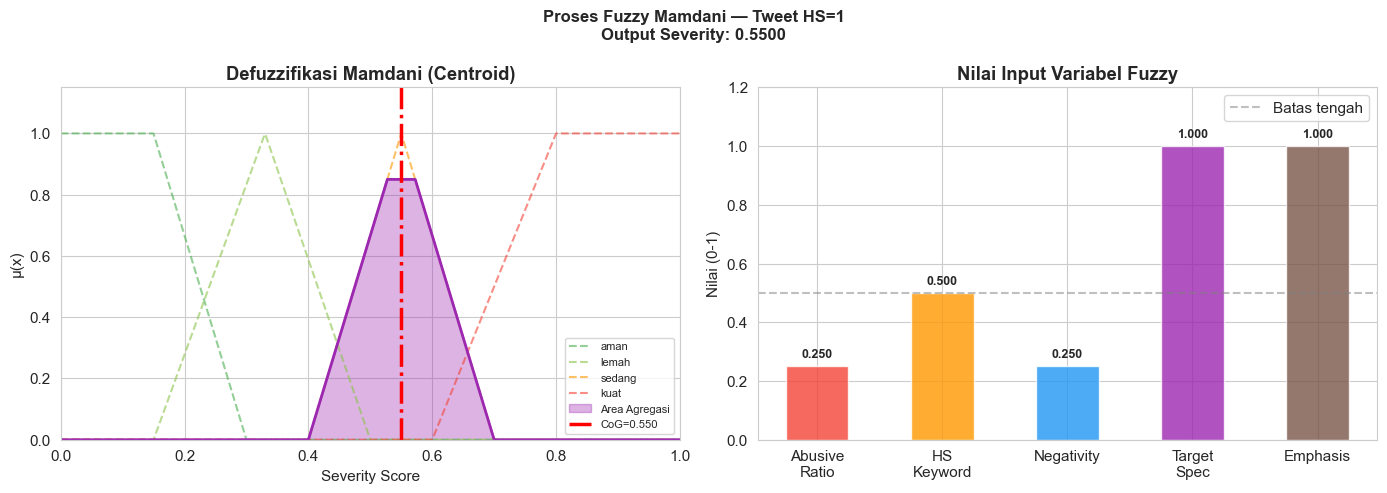

Tweet   : - disaat semua cowok berusaha melacak perhatian gue. loe lantas remehkan perhati...
Features: ar=0.250, hs=0.500, neg=0.250, tgt=1.000, emp=1.000
Severity Mamdani: 0.5500 → Sedang


In [51]:
# ── Visualisasi Proses Mamdani secara Detail untuk 1 Sampel ──
# Pilih sampel menarik: HS=1 (hate speech)
hs_samples = df[df['HS'] == 1].head(1).iloc[0]

AR  = hs_samples['f_abusive_ratio']
HS_ = hs_samples['f_hs_keyword']
NEG = hs_samples['f_negativity']
TGT = hs_samples['f_target_spec']
EMP = hs_samples['f_emphasis']

# Fuzzifikasi pure Mamdani
mu = fuzzy_mamdani.fuzzify(AR, HS_, NEG, TGT, EMP)
activations = fuzzy_mamdani.infer(mu)
aggregated  = fuzzy_mamdani.aggregate(activations)
cog         = fuzzy_mamdani.defuzzify(aggregated)

x_out = np.linspace(0, 1, 1000)
out_mf = mf_severity(x_out)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Kiri: Output MF + Aggregated + CoG
colors_out = {'aman':'#4CAF50','lemah':'#8BC34A','sedang':'#FF9800','kuat':'#F44336'}
ax = axes[0]
for lbl, y in out_mf.items():
    ax.plot(x_out, y, label=lbl, color=colors_out[lbl], linewidth=1.5, linestyle='--', alpha=0.6)
ax.fill_between(x_out, aggregated, alpha=0.35, color='#9C27B0', label='Area Agregasi')
ax.plot(x_out, aggregated, color='#9C27B0', linewidth=2)
ax.axvline(cog, color='red', linewidth=2.5, linestyle='-.', label=f'CoG={cog:.3f}')
ax.set_title('Defuzzifikasi Mamdani (Centroid)', fontweight='bold')
ax.set_xlabel('Severity Score'); ax.set_ylabel('μ(x)')
ax.legend(fontsize=8); ax.set_xlim(0,1); ax.set_ylim(0,1.15)

# Kanan: Nilai input fuzzy
ax2 = axes[1]
labels_in   = ['Abusive\nRatio', 'HS\nKeyword', 'Negativity', 'Target\nSpec', 'Emphasis']
values_in   = [AR, HS_, NEG, TGT, EMP]
bar_colors  = ['#F44336','#FF9800','#2196F3','#9C27B0','#795548']

bars = ax2.bar(labels_in, values_in, color=bar_colors, width=0.5, alpha=0.8)
for bar, val in zip(bars, values_in):
    ax2.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.02,
             f'{val:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=9)
ax2.set_title('Nilai Input Variabel Fuzzy', fontweight='bold')
ax2.set_ylabel('Nilai (0-1)'); ax2.set_ylim(0, 1.2)
ax2.axhline(0.5, linestyle='--', color='gray', alpha=0.5, label='Batas tengah')
ax2.legend()

plt.suptitle(f'Proses Fuzzy Mamdani — Tweet HS=1\nOutput Severity: {cog:.4f}',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('mamdani_process.png', bbox_inches='tight')
plt.show()

print(f'Tweet   : {hs_samples["Tweet"][:80]}...')
print(f'Features: ar={AR:.3f}, hs={HS_:.3f}, neg={NEG:.3f}, tgt={TGT:.3f}, emp={EMP:.3f}')
print(f'Severity Mamdani: {cog:.4f} → {["Aman","Lemah","Sedang","Kuat"][score_to_label(cog)]}')


## 10. Evaluasi & Perbandingan Mamdani vs Sugeno

In [52]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

gt = df.loc[test_idx, 'severity_score'].values
hs = df.loc[test_idx, 'HS'].values

mamdani_score_test = df.loc[test_idx, 'mamdani_score'].values
sugeno_score_test  = df.loc[test_idx, 'sugeno_score'].values

# ── Metrik Regresi (MAE, MSE, RMSE) ──
mae_m  = mean_absolute_error(gt, mamdani_score_test)
mse_m  = mean_squared_error(gt,  mamdani_score_test)
rmse_m = np.sqrt(mse_m)

mae_s  = mean_absolute_error(gt, sugeno_score_test)
mse_s  = mean_squared_error(gt,  sugeno_score_test)
rmse_s = np.sqrt(mse_s)

# ── Metrik Klasifikasi (HS binary) ──
acc_m = accuracy_score(hs, df.loc[test_idx, 'mamdani_hs_pred'])
f1_m  = f1_score(hs, df.loc[test_idx, 'mamdani_hs_pred'], average='weighted', zero_division=0)
auc_m = roc_auc_score(hs, mamdani_score_test)

acc_s = accuracy_score(hs, df.loc[test_idx, 'sugeno_hs_pred'])
f1_s  = f1_score(hs, df.loc[test_idx, 'sugeno_hs_pred'], average='weighted', zero_division=0)
auc_s = roc_auc_score(hs, sugeno_score_test)

# ── Korelasi antara Mamdani & Sugeno ──
corr = np.corrcoef(mamdani_score_test, sugeno_score_test)[0,1]

print('═'*55)
print(f'{"Metrik":<22} {"Mamdani":>14} {"Sugeno":>14}')
print('─'*55)
print(f'{"MAE":<22} {mae_m:>14.4f} {mae_s:>14.4f}')
print(f'{"MSE":<22} {mse_m:>14.4f} {mse_s:>14.4f}')
print(f'{"RMSE":<22} {rmse_m:>14.4f} {rmse_s:>14.4f}')
print('─'*55)
print(f'{"Accuracy (HS)":<22} {acc_m:>14.4f} {acc_s:>14.4f}')
print(f'{"F1-Score (HS)":<22} {f1_m:>14.4f} {f1_s:>14.4f}')
print(f'{"ROC-AUC (HS)":<22} {auc_m:>14.4f} {auc_s:>14.4f}')
print('─'*55)
print(f'{"Korelasi M↔S":<22} {corr:>14.4f}')
print('═'*55)

═══════════════════════════════════════════════════════
Metrik                        Mamdani         Sugeno
───────────────────────────────────────────────────────
MAE                            0.2868         0.2955
MSE                            0.1271         0.1389
RMSE                           0.3565         0.3726
───────────────────────────────────────────────────────
Accuracy (HS)                  0.6784         0.6784
F1-Score (HS)                  0.6784         0.6784
ROC-AUC (HS)                   0.6665         0.6635
───────────────────────────────────────────────────────
Korelasi M↔S                   0.9970
═══════════════════════════════════════════════════════


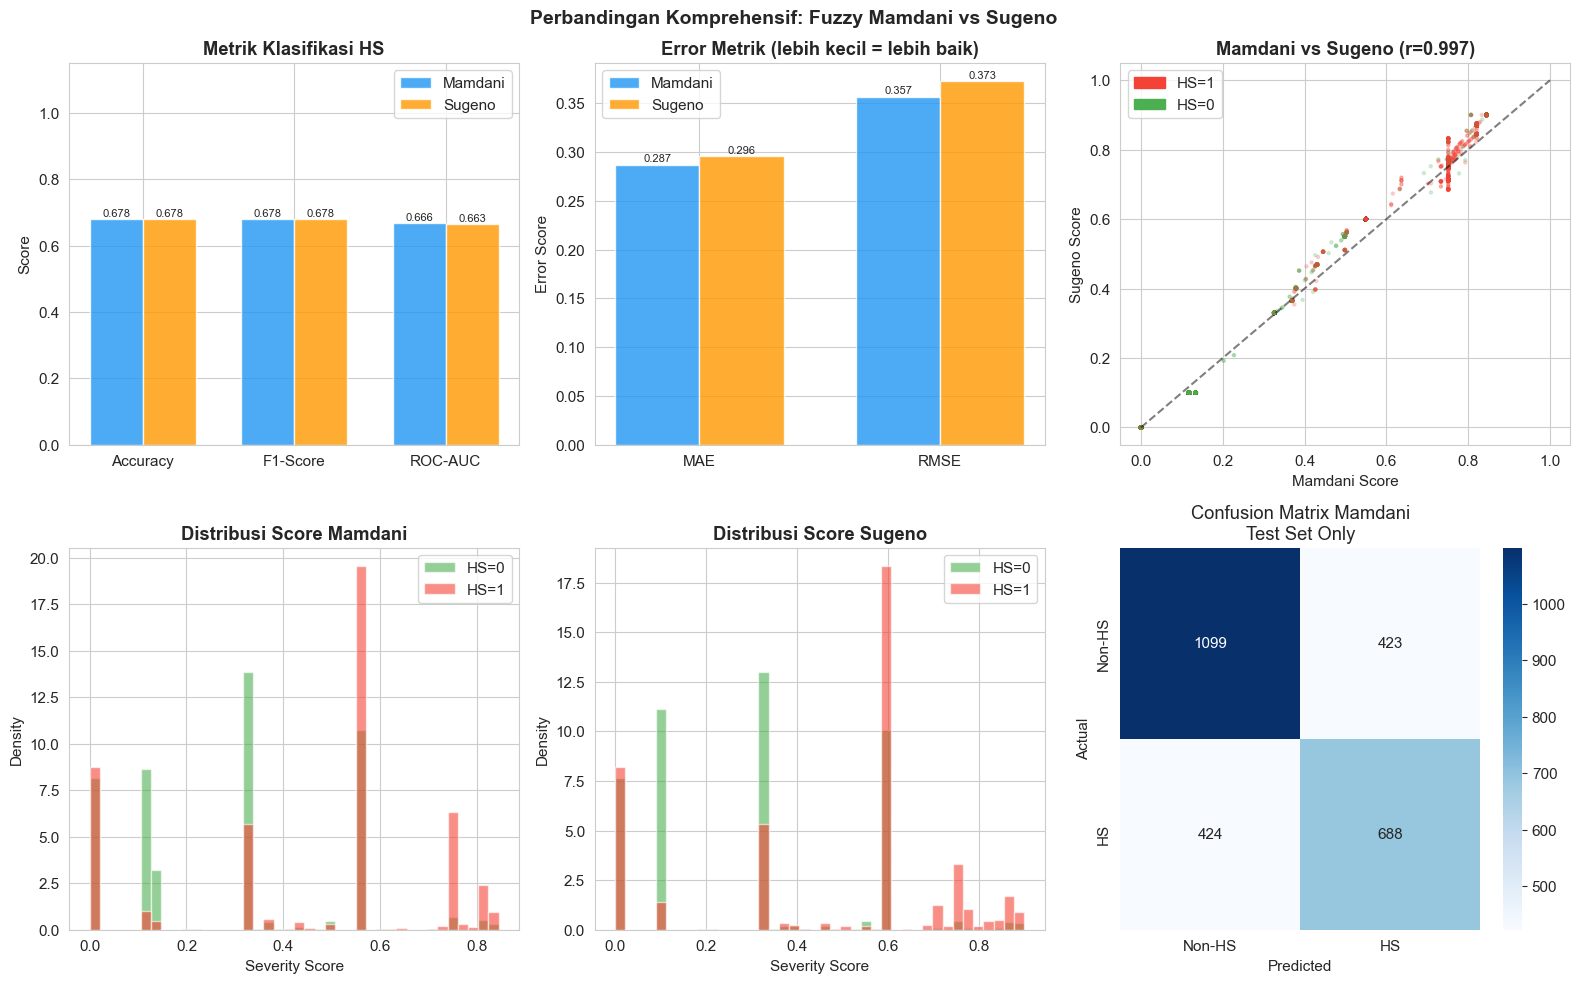

In [53]:
# ── Visualisasi Perbandingan Komprehensif ──
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Plot 1: Bar metrik performa
ax = axes[0,0]
metrics_labels = ['Accuracy', 'F1-Score', 'ROC-AUC']
mamdani_vals   = [acc_m, f1_m, auc_m]
sugeno_vals    = [acc_s, f1_s, auc_s]
x = np.arange(len(metrics_labels))
width = 0.35
b1 = ax.bar(x - width/2, mamdani_vals, width, label='Mamdani', color='#2196F3', alpha=0.8)
b2 = ax.bar(x + width/2, sugeno_vals,  width, label='Sugeno',  color='#FF9800', alpha=0.8)
ax.set_xticks(x); ax.set_xticklabels(metrics_labels)
ax.set_ylim(0, 1.15); ax.set_ylabel('Score')
ax.set_title('Metrik Klasifikasi HS', fontweight='bold')
ax.legend()
for b, v in zip(list(b1)+list(b2), mamdani_vals+sugeno_vals):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.01, f'{v:.3f}', ha='center', fontsize=8)

# Plot 2: MAE / RMSE Bar
ax = axes[0,1]
err_labels = ['MAE', 'RMSE']
err_m = [mae_m, rmse_m]
err_s = [mae_s, rmse_s]
x2 = np.arange(len(err_labels))
b3 = ax.bar(x2 - width/2, err_m, width, label='Mamdani', color='#2196F3', alpha=0.8)
b4 = ax.bar(x2 + width/2, err_s, width, label='Sugeno',  color='#FF9800', alpha=0.8)
ax.set_xticks(x2); ax.set_xticklabels(err_labels)
ax.set_title('Error Metrik (lebih kecil = lebih baik)', fontweight='bold')
ax.set_ylabel('Error Score')
ax.legend()
for b, v in zip(list(b3)+list(b4), err_m+err_s):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.003, f'{v:.3f}', ha='center', fontsize=8)

# Plot 3: Scatter Mamdani vs Sugeno
ax = axes[0,2]
colors_scatter = df['HS'].map({0:'#4CAF50', 1:'#F44336'})
ax.scatter(df['mamdani_score'], df['sugeno_score'], c=colors_scatter, alpha=0.2, s=5)
ax.plot([0,1],[0,1], 'k--', alpha=0.5, label='Ideal')
ax.set_xlabel('Mamdani Score'); ax.set_ylabel('Sugeno Score')
ax.set_title(f'Mamdani vs Sugeno (r={corr:.3f})', fontweight='bold')
hs_patch  = mpatches.Patch(color='#F44336', label='HS=1')
nhs_patch = mpatches.Patch(color='#4CAF50', label='HS=0')
ax.legend(handles=[hs_patch, nhs_patch])

# Plot 4: Distribusi Score Mamdani
ax = axes[1,0]
ax.hist(df[df['HS']==0]['mamdani_score'], bins=40, alpha=0.6, color='#4CAF50', label='HS=0', density=True)
ax.hist(df[df['HS']==1]['mamdani_score'], bins=40, alpha=0.6, color='#F44336', label='HS=1', density=True)
ax.set_title('Distribusi Score Mamdani', fontweight='bold')
ax.set_xlabel('Severity Score'); ax.set_ylabel('Density')
ax.legend()

# Plot 5: Distribusi Score Sugeno
ax = axes[1,1]
ax.hist(df[df['HS']==0]['sugeno_score'], bins=40, alpha=0.6, color='#4CAF50', label='HS=0', density=True)
ax.hist(df[df['HS']==1]['sugeno_score'], bins=40, alpha=0.6, color='#F44336', label='HS=1', density=True)
ax.set_title('Distribusi Score Sugeno', fontweight='bold')
ax.set_xlabel('Severity Score'); ax.set_ylabel('Density')
ax.legend()

# Plot 6: Confusion Matrix Mamdani vs Sugeno (HS biner)
ax = axes[1, 2]

y_true_test = df.loc[test_idx, 'HS'].values
y_pred_m_test = df.loc[test_idx, 'mamdani_hs_pred'].values
y_pred_s_test = df.loc[test_idx, 'sugeno_hs_pred'].values

cm_m = confusion_matrix(y_true_test, y_pred_m_test, labels=[0, 1])
cm_s = confusion_matrix(y_true_test, y_pred_s_test, labels=[0, 1])

sns.heatmap(
    cm_m,
    annot=True,
    fmt='d',
    cmap='Blues',
    ax=ax,
    xticklabels=['Non-HS', 'HS'],
    yticklabels=['Non-HS', 'HS']
)

ax.set_title('Confusion Matrix Mamdani\nTest Set Only')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')

plt.suptitle('Perbandingan Komprehensif: Fuzzy Mamdani vs Sugeno',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('comparison.png', bbox_inches='tight')
plt.show()

## 11. Analisis Mendalam: Perbedaan Output Mamdani vs Sugeno

In [54]:
# ── Analisis Tweet dengan selisih output terbesar ──
df['score_diff'] = np.abs(df['mamdani_score'] - df['sugeno_score'])

print('=== 5 Tweet dengan Perbedaan Output Terbesar ===')
top_diff = df.nlargest(5, 'score_diff')[['Tweet','HS','mamdani_score','sugeno_score','score_diff']]
for _, row in top_diff.iterrows():
    print(f'Tweet  : {row["Tweet"][:70]}...')
    print(f'HS={row["HS"]} | Mamdani={row["mamdani_score"]:.3f} | Sugeno={row["sugeno_score"]:.3f} | Δ={row["score_diff"]:.3f}')
    print()

print('=== Statistik Perbedaan Output ===')
print(f'Mean Δ  : {df["score_diff"].mean():.4f}')
print(f'Median Δ: {df["score_diff"].median():.4f}')
print(f'Max Δ   : {df["score_diff"].max():.4f}')
print(f'Std Δ   : {df["score_diff"].std():.4f}')

# Kasus di mana Mamdani dan Sugeno berbeda prediksi HS
disagree = df[df['mamdani_hs_pred'] != df['sugeno_hs_pred']]
print(f'\nJumlah ketidaksepakatan (HS pred berbeda): {len(disagree):,} ({len(disagree)/len(df)*100:.1f}%)')

=== 5 Tweet dengan Perbedaan Output Terbesar ===
Tweet  : USER Pernyataan anda sllu menyudutkan pemerintah..sungguh naif &amp; m...
HS=1 | Mamdani=0.806 | Sugeno=0.900 | Δ=0.094

Tweet  : USER Tiap berkicau makin keliatan tolol dan gobloknya, lbh tolol lg yg...
HS=1 | Mamdani=0.807 | Sugeno=0.900 | Δ=0.093

Tweet  : Saya nggak alim-alim amat, tapi juga nggak bodoh-bodoh amat untuk melu...
HS=0 | Mamdani=0.807 | Sugeno=0.900 | Δ=0.093

Tweet  : USER Ihh yg bener anjirr jahat elu mah bodo bodo'...
HS=0 | Mamdani=0.807 | Sugeno=0.900 | Δ=0.093

Tweet  : USER USER USER Jangan maaf ama saya bang... Kan kita mah kaga ada sala...
HS=0 | Mamdani=0.807 | Sugeno=0.900 | Δ=0.093

=== Statistik Perbedaan Output ===
Mean Δ  : 0.0238
Median Δ: 0.0164
Max Δ   : 0.0936
Std Δ   : 0.0218

Jumlah ketidaksepakatan (HS pred berbeda): 0 (0.0%)


In [55]:
# ── Classification Report Lengkap ──
# Evaluasi hanya pada test set

y_true_test = df.loc[test_idx, 'HS'].values

y_pred_m_test = df.loc[test_idx, 'mamdani_hs_pred'].values
y_pred_s_test = df.loc[test_idx, 'sugeno_hs_pred'].values

print('=== Classification Report: Fuzzy MAMDANI — Test Set ===')
print(classification_report(
    y_true_test,
    y_pred_m_test,
    target_names=['Bukan HS', 'Hate Speech']
))

print('=== Classification Report: Fuzzy SUGENO — Test Set ===')
print(classification_report(
    y_true_test,
    y_pred_s_test,
    target_names=['Bukan HS', 'Hate Speech']
))

=== Classification Report: Fuzzy MAMDANI — Test Set ===
              precision    recall  f1-score   support

    Bukan HS       0.72      0.72      0.72      1522
 Hate Speech       0.62      0.62      0.62      1112

    accuracy                           0.68      2634
   macro avg       0.67      0.67      0.67      2634
weighted avg       0.68      0.68      0.68      2634

=== Classification Report: Fuzzy SUGENO — Test Set ===
              precision    recall  f1-score   support

    Bukan HS       0.72      0.72      0.72      1522
 Hate Speech       0.62      0.62      0.62      1112

    accuracy                           0.68      2634
   macro avg       0.67      0.67      0.67      2634
weighted avg       0.68      0.68      0.68      2634



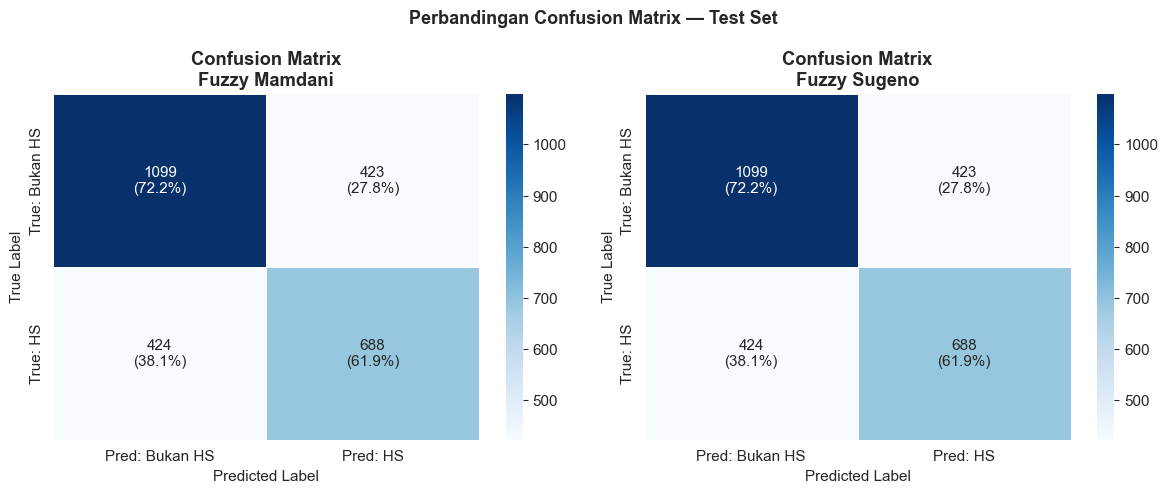

In [56]:
# ── Confusion Matrices Side by Side ──
# Evaluasi hanya pada test set

y_true_test = df.loc[test_idx, 'HS'].values

preds_mamdani = df.loc[test_idx, 'mamdani_hs_pred'].values
preds_sugeno  = df.loc[test_idx, 'sugeno_hs_pred'].values

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, preds, title in zip(
    axes,
    [preds_mamdani, preds_sugeno],
    ['Fuzzy Mamdani', 'Fuzzy Sugeno']
):
    cm = confusion_matrix(y_true_test, preds, labels=[0, 1])

    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

    annot = np.array([
        [f'{v}\n({p:.1f}%)' for v, p in zip(row_v, row_p)]
        for row_v, row_p in zip(cm, cm_pct)
    ])

    sns.heatmap(
        cm,
        annot=annot,
        fmt='',
        cmap='Blues',
        ax=ax,
        xticklabels=['Pred: Bukan HS', 'Pred: HS'],
        yticklabels=['True: Bukan HS', 'True: HS'],
        linewidths=0.5
    )

    ax.set_title(f'Confusion Matrix\n{title}', fontweight='bold')
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')

plt.suptitle('Perbandingan Confusion Matrix — Test Set', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrices.png', bbox_inches='tight')
plt.show()

## 12. Bonus: Integrasi Fuzzy Logic + Deep Learning (Hybrid System)

In [57]:
# ═══════════════════════════════════════════════════════════════
# HYBRID SYSTEM: LSTM + FUZZY MAMDANI & SUGENO
# ═══════════════════════════════════════════════════════════════

# Hybrid Mamdani
fuzzy_hybrid_mamdani = FuzzyMamdani(ruleset=rules_hybrid, use_dl=True)

print('Menjalankan Hybrid LSTM + Mamdani...')
df['hybrid_mamdani_score'] = fuzzy_hybrid_mamdani.predict_batch(df)

hybrid_mamdani_threshold, hybrid_mamdani_val_score = tune_threshold(
    df.loc[val_idx, 'hybrid_mamdani_score'].values,
    df.loc[val_idx, 'HS'].values,
    metric=THRESHOLD_METRIC
)

df['hybrid_mamdani_hs_pred'] = (
    df['hybrid_mamdani_score'] >= hybrid_mamdani_threshold
).astype(int)


# Hybrid Sugeno
fuzzy_hybrid_sugeno = FuzzySugeno(ruleset=rules_hybrid, use_dl=True)

print('Menjalankan Hybrid LSTM + Sugeno...')
df['hybrid_sugeno_score'] = fuzzy_hybrid_sugeno.predict_batch(df)

hybrid_sugeno_threshold, hybrid_sugeno_val_score = tune_threshold(
    df.loc[val_idx, 'hybrid_sugeno_score'].values,
    df.loc[val_idx, 'HS'].values,
    metric=THRESHOLD_METRIC
)

df['hybrid_sugeno_hs_pred'] = (
    df['hybrid_sugeno_score'] >= hybrid_sugeno_threshold
).astype(int)


# Evaluasi Hybrid Mamdani pada test set
y_pred_hm_test = df.loc[test_idx, 'hybrid_mamdani_hs_pred'].values
y_score_hm_test = df.loc[test_idx, 'hybrid_mamdani_score'].values

acc_hybrid_m = accuracy_score(y_true_test, y_pred_hm_test)
f1_hybrid_m  = f1_score(y_true_test, y_pred_hm_test, average='weighted', zero_division=0)
auc_hybrid_m = roc_auc_score(y_true_test, y_score_hm_test)


# Evaluasi Hybrid Sugeno pada test set
y_pred_hs_test = df.loc[test_idx, 'hybrid_sugeno_hs_pred'].values
y_score_hs_test = df.loc[test_idx, 'hybrid_sugeno_score'].values

acc_hybrid_s = accuracy_score(y_true_test, y_pred_hs_test)
f1_hybrid_s  = f1_score(y_true_test, y_pred_hs_test, average='weighted', zero_division=0)
auc_hybrid_s = roc_auc_score(y_true_test, y_score_hs_test)


# ═══════════════════════════════════════════════════════════════
# WEIGHTED HYBRID SCORE
# ═══════════════════════════════════════════════════════════════
# alpha = bobot fuzzy score
# 1-alpha = bobot DL probability
# alpha dan threshold dituning hanya pada validation set.

def tune_weighted_hybrid(fuzzy_scores, dl_scores, y_true, metric='accuracy'):
    best_alpha = 0.0
    best_threshold = 0.5
    best_score = -1

    for alpha in np.arange(0.0, 1.01, 0.05):
        hybrid_scores = alpha * fuzzy_scores + (1 - alpha) * dl_scores

        threshold, score = tune_threshold(
            hybrid_scores,
            y_true,
            metric=metric
        )

        if score > best_score:
            best_score = score
            best_alpha = alpha
            best_threshold = threshold

    return float(best_alpha), float(best_threshold), float(best_score)


# Weighted Hybrid Mamdani
alpha_m, threshold_weighted_m, val_score_weighted_m = tune_weighted_hybrid(
    df.loc[val_idx, 'mamdani_score'].values,
    df.loc[val_idx, 'f_dl_abusive'].values,
    df.loc[val_idx, 'HS'].values,
    metric=THRESHOLD_METRIC
)

df['weighted_hybrid_mamdani_score'] = (
    alpha_m * df['mamdani_score'] +
    (1 - alpha_m) * df['f_dl_abusive']
)

df['weighted_hybrid_mamdani_hs_pred'] = (
    df['weighted_hybrid_mamdani_score'] >= threshold_weighted_m
).astype(int)

y_pred_whm_test = df.loc[test_idx, 'weighted_hybrid_mamdani_hs_pred'].values
y_score_whm_test = df.loc[test_idx, 'weighted_hybrid_mamdani_score'].values

acc_weighted_m = accuracy_score(y_true_test, y_pred_whm_test)
f1_weighted_m  = f1_score(y_true_test, y_pred_whm_test, average='weighted', zero_division=0)
auc_weighted_m = roc_auc_score(y_true_test, y_score_whm_test)


# Weighted Hybrid Sugeno
alpha_s, threshold_weighted_s, val_score_weighted_s = tune_weighted_hybrid(
    df.loc[val_idx, 'sugeno_score'].values,
    df.loc[val_idx, 'f_dl_abusive'].values,
    df.loc[val_idx, 'HS'].values,
    metric=THRESHOLD_METRIC
)

df['weighted_hybrid_sugeno_score'] = (
    alpha_s * df['sugeno_score'] +
    (1 - alpha_s) * df['f_dl_abusive']
)

df['weighted_hybrid_sugeno_hs_pred'] = (
    df['weighted_hybrid_sugeno_score'] >= threshold_weighted_s
).astype(int)

y_pred_whs_test = df.loc[test_idx, 'weighted_hybrid_sugeno_hs_pred'].values
y_score_whs_test = df.loc[test_idx, 'weighted_hybrid_sugeno_score'].values

acc_weighted_s = accuracy_score(y_true_test, y_pred_whs_test)
f1_weighted_s  = f1_score(y_true_test, y_pred_whs_test, average='weighted', zero_division=0)
auc_weighted_s = roc_auc_score(y_true_test, y_score_whs_test)


print()
print('════════════════════════════════════════════════════════════════════')
print('Dampak Integrasi Deep Learning pada Sistem Fuzzy — Test Set')
print('Threshold metric:', THRESHOLD_METRIC)
print('────────────────────────────────────────────────────────────────────')
print(f'{"Sistem":<32} {"Threshold":>10} {"Accuracy":>10} {"F1-Score":>10} {"ROC-AUC":>10}')
print('────────────────────────────────────────────────────────────────────')
print(f'{"Pure Mamdani":<32} {mamdani_threshold:>10.2f} {acc_m:>10.4f} {f1_m:>10.4f} {auc_m:>10.4f}')
print(f'{"Hybrid Rule Mamdani":<32} {hybrid_mamdani_threshold:>10.2f} {acc_hybrid_m:>10.4f} {f1_hybrid_m:>10.4f} {auc_hybrid_m:>10.4f}')
print(f'{"Weighted Hybrid Mamdani":<32} {threshold_weighted_m:>10.2f} {acc_weighted_m:>10.4f} {f1_weighted_m:>10.4f} {auc_weighted_m:>10.4f}')
print(f'{"Pure Sugeno":<32} {sugeno_threshold:>10.2f} {acc_s:>10.4f} {f1_s:>10.4f} {auc_s:>10.4f}')
print(f'{"Hybrid Rule Sugeno":<32} {hybrid_sugeno_threshold:>10.2f} {acc_hybrid_s:>10.4f} {f1_hybrid_s:>10.4f} {auc_hybrid_s:>10.4f}')
print(f'{"Weighted Hybrid Sugeno":<32} {threshold_weighted_s:>10.2f} {acc_weighted_s:>10.4f} {f1_weighted_s:>10.4f} {auc_weighted_s:>10.4f}')
print('────────────────────────────────────────────────────────────────────')
print(f'Best alpha Mamdani weighted: {alpha_m:.2f} fuzzy + {1-alpha_m:.2f} DL')
print(f'Best alpha Sugeno weighted : {alpha_s:.2f} fuzzy + {1-alpha_s:.2f} DL')
print('════════════════════════════════════════════════════════════════════')


Menjalankan Hybrid LSTM + Mamdani...
Menjalankan Hybrid LSTM + Sugeno...

════════════════════════════════════════════════════════════════════
Dampak Integrasi Deep Learning pada Sistem Fuzzy — Test Set
Threshold metric: accuracy
────────────────────────────────────────────────────────────────────
Sistem                            Threshold   Accuracy   F1-Score    ROC-AUC
────────────────────────────────────────────────────────────────────
Pure Mamdani                           0.50     0.6784     0.6784     0.6665
Hybrid Rule Mamdani                    0.34     0.6887     0.6891     0.6738
Weighted Hybrid Mamdani                0.47     0.6982     0.6868     0.6995
Pure Sugeno                            0.56     0.6784     0.6784     0.6635
Hybrid Rule Sugeno                     0.42     0.6841     0.6838     0.6764
Weighted Hybrid Sugeno                 0.50     0.6986     0.6829     0.7019
────────────────────────────────────────────────────────────────────
Best alpha Mamdani weigh

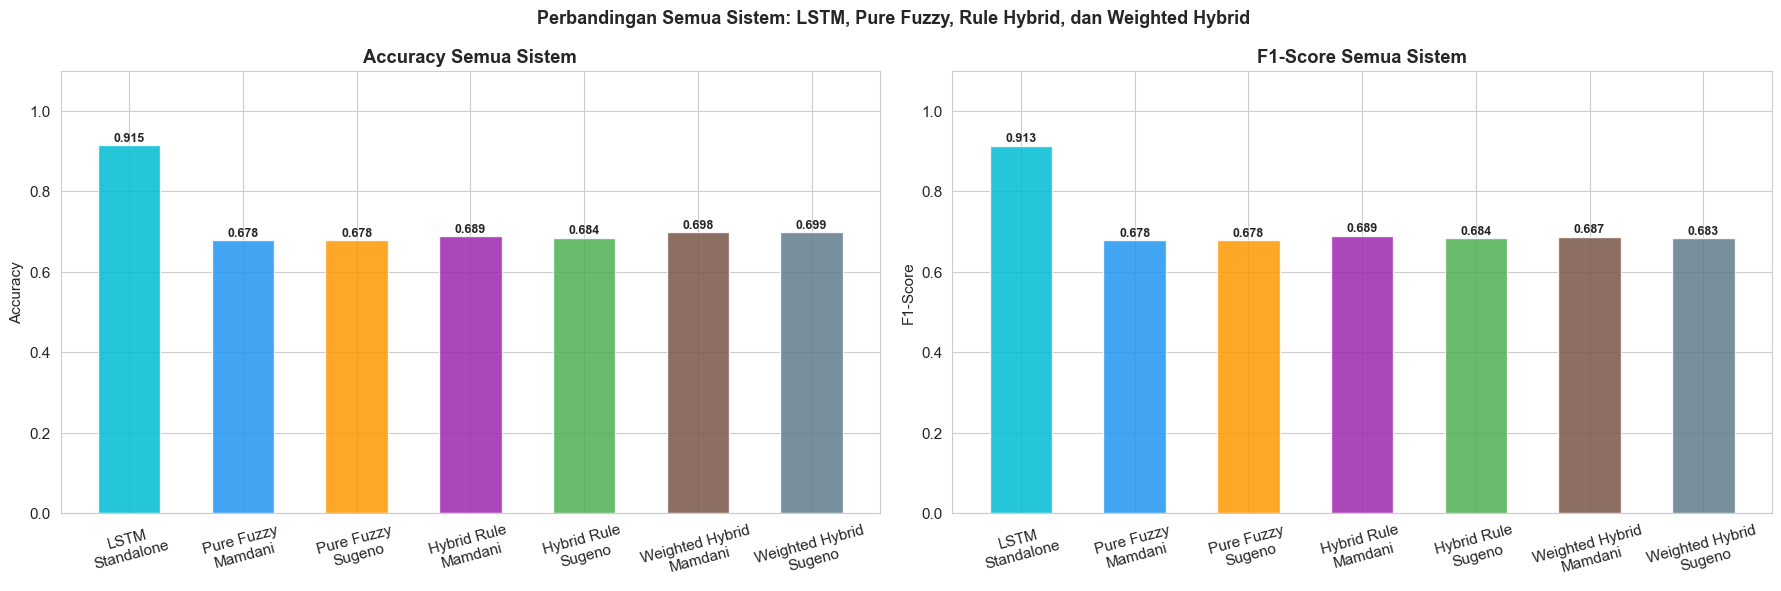

In [58]:
# ── Ringkasan Final: Semua Sistem ──
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

systems = [
    'LSTM\nStandalone',
    'Pure Fuzzy\nMamdani',
    'Pure Fuzzy\nSugeno',
    'Hybrid Rule\nMamdani',
    'Hybrid Rule\nSugeno',
    'Weighted Hybrid\nMamdani',
    'Weighted Hybrid\nSugeno'
]

accuracies = [
    accuracy_score(y_test, y_pred_test),
    acc_m,
    acc_s,
    acc_hybrid_m,
    acc_hybrid_s,
    acc_weighted_m,
    acc_weighted_s
]

f1scores = [
    f1_score(y_test, y_pred_test, average='weighted', zero_division=0),
    f1_m,
    f1_s,
    f1_hybrid_m,
    f1_hybrid_s,
    f1_weighted_m,
    f1_weighted_s
]

colors_sys = ['#00BCD4', '#2196F3', '#FF9800', '#9C27B0', '#4CAF50', '#795548', '#607D8B']

ax = axes[0]
bars = ax.bar(systems, accuracies, color=colors_sys, alpha=0.85, width=0.55)
ax.set_title('Accuracy Semua Sistem', fontweight='bold')
ax.set_ylabel('Accuracy'); ax.set_ylim(0, 1.1)
ax.tick_params(axis='x', labelrotation=15)
for b, v in zip(bars, accuracies):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.01, f'{v:.3f}',
            ha='center', fontweight='bold', fontsize=9)

ax = axes[1]
bars = ax.bar(systems, f1scores, color=colors_sys, alpha=0.85, width=0.55)
ax.set_title('F1-Score Semua Sistem', fontweight='bold')
ax.set_ylabel('F1-Score'); ax.set_ylim(0, 1.1)
ax.tick_params(axis='x', labelrotation=15)
for b, v in zip(bars, f1scores):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.01, f'{v:.3f}',
            ha='center', fontweight='bold', fontsize=9)

plt.suptitle(
    'Perbandingan Semua Sistem: LSTM, Pure Fuzzy, Rule Hybrid, dan Weighted Hybrid',
    fontsize=13,
    fontweight='bold'
)
plt.tight_layout()
plt.savefig('all_systems.png', bbox_inches='tight')
plt.show()


### 12.2 Diagnostic: Error Pattern dan Threshold


In [59]:
# ── Diagnostic: lihat apakah akurasi dibatasi oleh false positive atau false negative ──

def inspect_errors(name, pred_col):
    y_true = df.loc[test_idx, 'HS'].values
    y_pred = df.loc[test_idx, pred_col].values

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    fpr = fp / (fp + tn) if (fp + tn) else 0
    fnr = fn / (fn + tp) if (fn + tp) else 0

    print(name)
    print(f'TN: {tn} | FP: {fp} | FN: {fn} | TP: {tp}')
    print(f'False Positive Rate: {fpr:.3f}')
    print(f'False Negative Rate: {fnr:.3f}')
    print()

inspect_errors('Pure Mamdani', 'mamdani_hs_pred')
inspect_errors('Pure Sugeno', 'sugeno_hs_pred')
inspect_errors('Hybrid Rule Mamdani', 'hybrid_mamdani_hs_pred')
inspect_errors('Hybrid Rule Sugeno', 'hybrid_sugeno_hs_pred')
inspect_errors('Weighted Hybrid Mamdani', 'weighted_hybrid_mamdani_hs_pred')
inspect_errors('Weighted Hybrid Sugeno', 'weighted_hybrid_sugeno_hs_pred')


Pure Mamdani
TN: 1099 | FP: 423 | FN: 424 | TP: 688
False Positive Rate: 0.278
False Negative Rate: 0.381

Pure Sugeno
TN: 1099 | FP: 423 | FN: 424 | TP: 688
False Positive Rate: 0.278
False Negative Rate: 0.381

Hybrid Rule Mamdani
TN: 1100 | FP: 422 | FN: 398 | TP: 714
False Positive Rate: 0.277
False Negative Rate: 0.358

Hybrid Rule Sugeno
TN: 1115 | FP: 407 | FN: 425 | TP: 687
False Positive Rate: 0.267
False Negative Rate: 0.382

Weighted Hybrid Mamdani
TN: 1288 | FP: 234 | FN: 561 | TP: 551
False Positive Rate: 0.154
False Negative Rate: 0.504

Weighted Hybrid Sugeno
TN: 1326 | FP: 196 | FN: 598 | TP: 514
False Positive Rate: 0.129
False Negative Rate: 0.538



## 13. Interpretasi & Analisis

In [60]:
print("""
╔══════════════════════════════════════════════════════════════════════╗
║           ANALISIS PERBANDINGAN: MAMDANI vs SUGENO                  ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  1. PERBAIKAN AKURASI YANG DITAMBAHKAN                              ║
║  • Threshold dituning pada validation set dengan metric: {:<12} ║
║  • f_hs_keyword diperkuat dengan keyword mining dari train set saja  ║
║  • Slang normalization ditambah untuk bentuk informal/typo umum      ║
║  • f_emphasis ditambah untuk menangkap kapital/tanda seru            ║
║  • Weighted Hybrid men-tune bobot fuzzy vs DL pada validation set    ║
║                                                                      ║
║  2. PERBEDAAN METODE DEFUZZIFIKASI                                   ║
║  • Mamdani: Centroid of Gravity (CoG)                                ║
║    - Membentuk area agregasi dari semua rule yang aktif              ║
║    - Lebih ekspresif karena output berupa fungsi keanggotaan penuh   ║
║  • Sugeno: Weighted Average                                          ║
║    - Output setiap rule adalah konstanta (0.10/0.33/0.60/0.90)       ║
║    - Lebih efisien secara komputasi                                  ║
║                                                                      ║
║  3. PERFORMA PURE FUZZY                                              ║
║  • Mamdani Acc: {:.4f} | Sugeno Acc: {:.4f}                          ║
║  • Performa pure fuzzy wajar lebih rendah daripada neural model      ║
║    karena hanya memakai fitur lexical/rule-based.                    ║
║                                                                      ║
║  4. DAMPAK INTEGRASI DEEP LEARNING                                   ║
║  • Rule Hybrid memakai probabilitas DL sebagai input fuzzy tambahan  ║
║  • Weighted Hybrid mencari bobot optimal fuzzy vs DL                 ║
║  • Alpha Mamdani: {:.2f} fuzzy + {:.2f} DL                           ║
║  • Alpha Sugeno : {:.2f} fuzzy + {:.2f} DL                           ║
╚══════════════════════════════════════════════════════════════════════╝
""".format(
    THRESHOLD_METRIC,
    acc_m, acc_s,
    alpha_m, 1-alpha_m,
    alpha_s, 1-alpha_s
))



╔══════════════════════════════════════════════════════════════════════╗
║           ANALISIS PERBANDINGAN: MAMDANI vs SUGENO                  ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  1. PERBAIKAN AKURASI YANG DITAMBAHKAN                              ║
║  • Threshold dituning pada validation set dengan metric: accuracy     ║
║  • f_hs_keyword diperkuat dengan keyword mining dari train set saja  ║
║  • Slang normalization ditambah untuk bentuk informal/typo umum      ║
║  • f_emphasis ditambah untuk menangkap kapital/tanda seru            ║
║  • Weighted Hybrid men-tune bobot fuzzy vs DL pada validation set    ║
║                                                                      ║
║  2. PERBEDAAN METODE DEFUZZIFIKASI                                   ║
║  • Mamdani: Centroid of Gravity (CoG)                                ║
║    - Membentuk area agregasi dari semua rule yang

In [61]:
summary = pd.DataFrame({
    'Sistem': [
        'BiLSTM Standalone',
        'Pure Fuzzy Mamdani',
        'Pure Fuzzy Sugeno',
        'Hybrid Rule LSTM + Mamdani',
        'Hybrid Rule LSTM + Sugeno',
        'Weighted Hybrid LSTM + Mamdani',
        'Weighted Hybrid LSTM + Sugeno'
    ],
    'Threshold': [
        0.50,
        round(mamdani_threshold, 2),
        round(sugeno_threshold, 2),
        round(hybrid_mamdani_threshold, 2),
        round(hybrid_sugeno_threshold, 2),
        round(threshold_weighted_m, 2),
        round(threshold_weighted_s, 2)
    ],
    'Accuracy': [
        round(accuracy_score(y_test, y_pred_test), 4),
        round(acc_m, 4),
        round(acc_s, 4),
        round(acc_hybrid_m, 4),
        round(acc_hybrid_s, 4),
        round(acc_weighted_m, 4),
        round(acc_weighted_s, 4)
    ],
    'F1-Score': [
        round(f1_score(y_test, y_pred_test, average='weighted', zero_division=0), 4),
        round(f1_m, 4),
        round(f1_s, 4),
        round(f1_hybrid_m, 4),
        round(f1_hybrid_s, 4),
        round(f1_weighted_m, 4),
        round(f1_weighted_s, 4)
    ],
    'ROC-AUC': [
        round(roc_auc_score(y_test, y_prob_test), 4),
        round(auc_m, 4),
        round(auc_s, 4),
        round(auc_hybrid_m, 4),
        round(auc_hybrid_s, 4),
        round(auc_weighted_m, 4),
        round(auc_weighted_s, 4)
    ]
})

print('=== TABEL RINGKASAN PERFORMA SEMUA SISTEM — TEST SET ===')
print(f'Threshold metric fuzzy/hybrid: {THRESHOLD_METRIC}')
print(summary.to_string(index=False))
print()
print(f'Dataset total : {len(df):,} tweets')
print(f'Train set     : {len(train_df):,} tweets')
print(f'Validation set: {len(val_df):,} tweets')
print(f'Test set      : {len(test_df):,} tweets')
print()
print('Sumber : Indonesian Hate Speech Detection Dataset')
print('Paper  : Ibrohim & Budi (2019)')


=== TABEL RINGKASAN PERFORMA SEMUA SISTEM — TEST SET ===
Threshold metric fuzzy/hybrid: accuracy
                        Sistem  Threshold  Accuracy  F1-Score  ROC-AUC
             BiLSTM Standalone       0.50    0.9146    0.9134   0.9665
            Pure Fuzzy Mamdani       0.50    0.6784    0.6784   0.6665
             Pure Fuzzy Sugeno       0.56    0.6784    0.6784   0.6635
    Hybrid Rule LSTM + Mamdani       0.34    0.6887    0.6891   0.6738
     Hybrid Rule LSTM + Sugeno       0.42    0.6841    0.6838   0.6764
Weighted Hybrid LSTM + Mamdani       0.47    0.6982    0.6868   0.6995
 Weighted Hybrid LSTM + Sugeno       0.50    0.6986    0.6829   0.7019

Dataset total : 13,169 tweets
Train set     : 7,901 tweets
Validation set: 2,634 tweets
Test set      : 2,634 tweets

Sumber : Indonesian Hate Speech Detection Dataset
Paper  : Ibrohim & Budi (2019)
